## I. Data Exploration

In [3]:
# Import all required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn import linear_model, metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error


In [4]:
# Load the dataset
data_path = '/Users/junqi/Desktop/BMW sales data (2010-2024).csv'

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (50000, 11)


### Dataset Overview & Summary Statistics

In [5]:
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

=== DATASET OVERVIEW ===
Shape: (50000, 11)

First 5 rows:
      Model  Year         Region  Color Fuel_Type Transmission  Engine_Size_L  \
0  5 Series  2016           Asia    Red    Petrol       Manual            3.5   
1        i8  2013  North America    Red    Hybrid    Automatic            1.6   
2  5 Series  2022  North America   Blue    Petrol    Automatic            4.5   
3        X3  2024    Middle East   Blue    Petrol    Automatic            1.7   
4  7 Series  2020  South America  Black    Diesel       Manual            2.1   

   Mileage_KM  Price_USD  Sales_Volume Sales_Classification  
0      151748      98740          8300                 High  
1      121671      79219          3428                  Low  
2       10991     113265          6994                  Low  
3       27255      60971          4047                  Low  
4      122131      49898          3080                  Low  


In [6]:
print("\nColumn names and data types:")
print(df.info())


Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB
None


In [7]:
print("\n=== SUMMARY STATISTICS ===")
print(df.describe())


=== SUMMARY STATISTICS ===
               Year  Engine_Size_L     Mileage_KM      Price_USD  Sales_Volume
count  50000.000000   50000.000000   50000.000000   50000.000000  50000.000000
mean    2017.015700       3.247180  100307.203140   75034.600900   5067.514680
std        4.324459       1.009078   57941.509344   25998.248882   2856.767125
min     2010.000000       1.500000       3.000000   30000.000000    100.000000
25%     2013.000000       2.400000   50178.000000   52434.750000   2588.000000
50%     2017.000000       3.200000  100388.500000   75011.500000   5087.000000
75%     2021.000000       4.100000  150630.250000   97628.250000   7537.250000
max     2024.000000       5.000000  199996.000000  119998.000000   9999.000000


In [8]:
# Display categorical columns summary
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")


Categorical columns: ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']


In [9]:
# Asses unique values for each non-numeric variable
for col in ["Model", "Region", "Color", "Fuel_Type", "Transmission", "Sales_Classification"]:
    print(col)
    print(df[col].unique())
    print()

Model
['5 Series' 'i8' 'X3' '7 Series' 'M5' '3 Series' 'X1' 'M3' 'X5' 'i3' 'X6']

Region
['Asia' 'North America' 'Middle East' 'South America' 'Europe' 'Africa']

Color
['Red' 'Blue' 'Black' 'Silver' 'White' 'Grey']

Fuel_Type
['Petrol' 'Hybrid' 'Diesel' 'Electric']

Transmission
['Manual' 'Automatic']

Sales_Classification
['High' 'Low']



### Missing Values Analysis

In [10]:
# List number and percentage of missing values per variable
print("=== MISSING VALUES ANALYSIS ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_info[missing_info['Missing Count'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 8))
missing_plot_data = missing_info[missing_info['Missing Count'] > 0]
if not missing_plot_data.empty:
    plt.bar(missing_plot_data.index, missing_plot_data['Missing Percentage'])
    plt.title('Missing Values Percentage by Column', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
    plt.ylabel('Percentage Missing (%)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

=== MISSING VALUES ANALYSIS ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


<Figure size 1000x800 with 0 Axes>

## II. Data Visualization

### Analysis of Numerical Variables

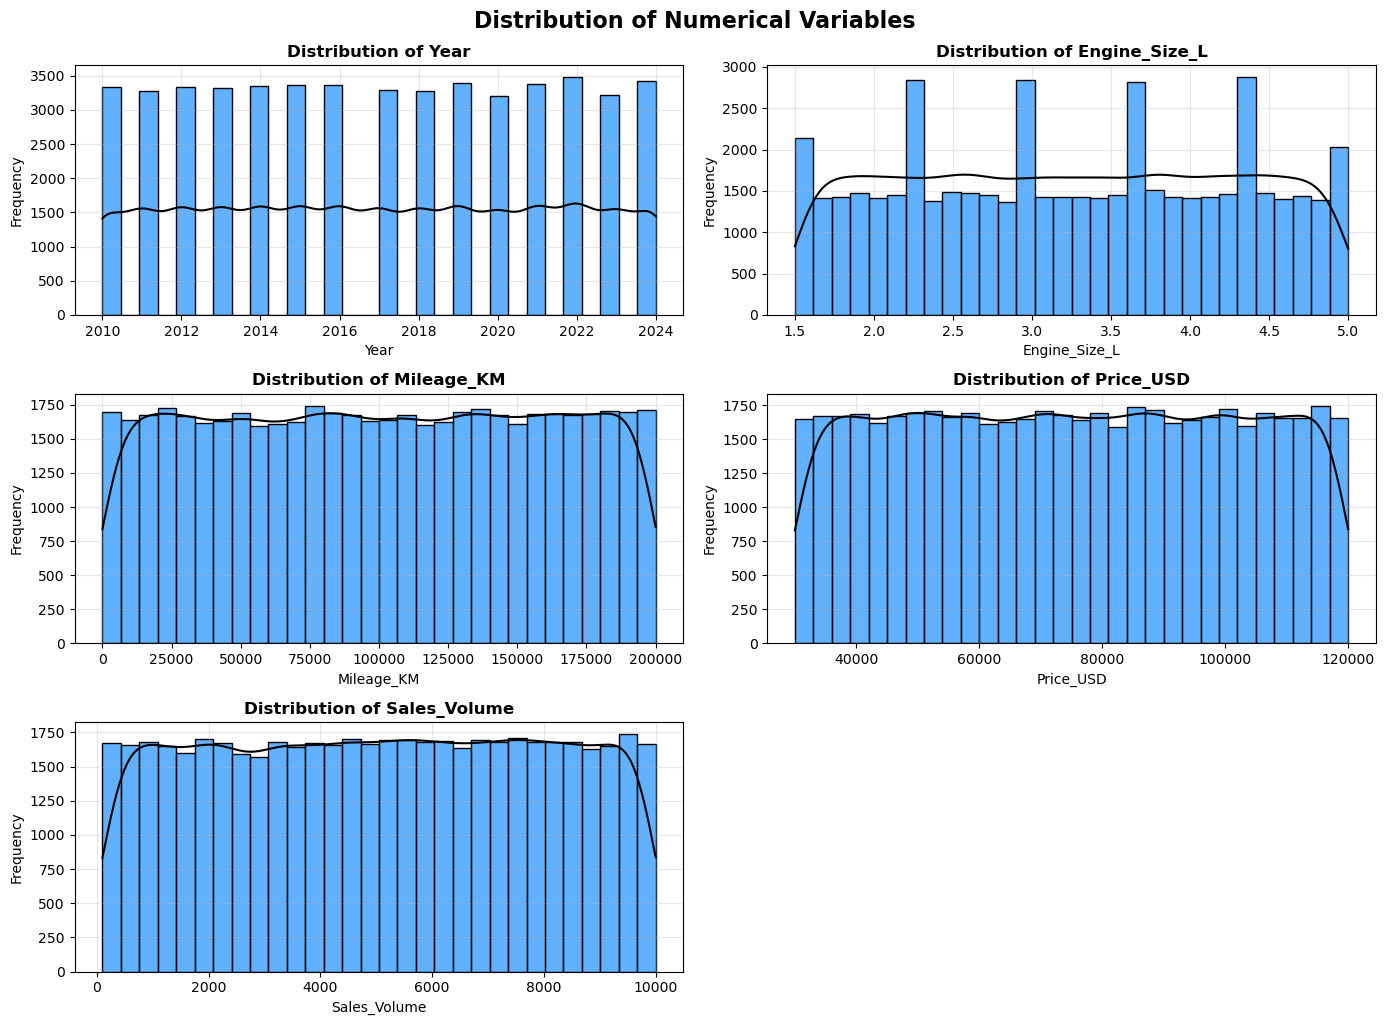

In [11]:
# Histograms for distribution of numerical variables

numerical_vars = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_vars):
    ax = axes[i]

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=ax,
        color='dodgerblue',
        edgecolor='black',
        alpha=0.7
    )
    if ax.lines:
        ax.lines[-1].set_color('black')
        ax.lines[-1].set_linewidth(1.5)

    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

for j in range(len(numerical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.show()

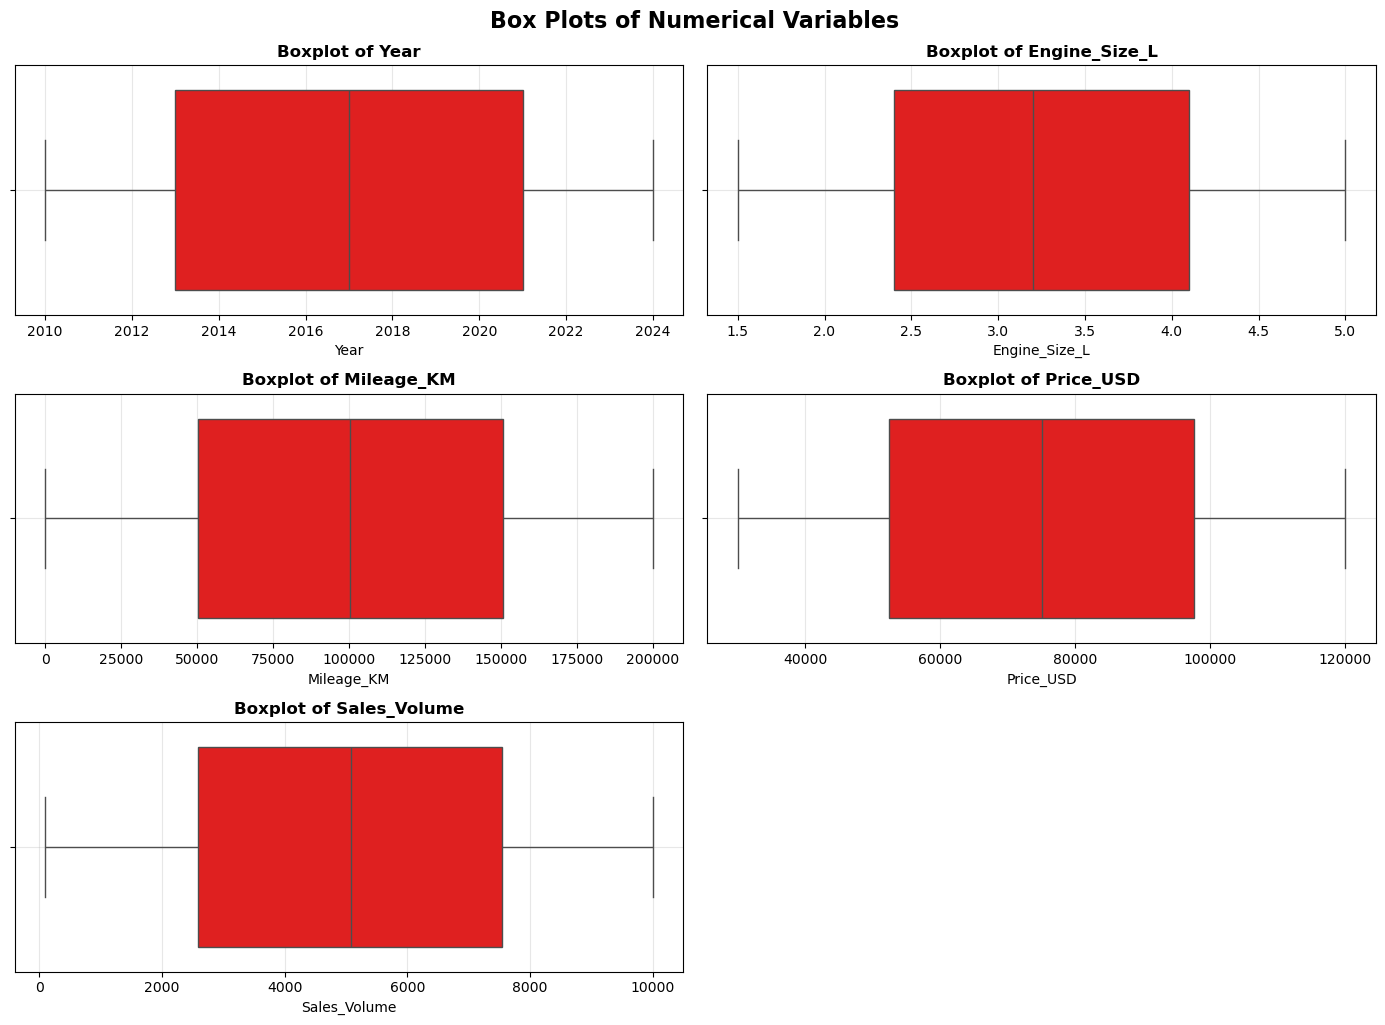

In [12]:
# Boxplot for distribution of numerical variables

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_vars):
    sns.boxplot(
        data=df,
        x=col,
        color="red",
        ax=axes[i]
    )

    axes[i].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].grid(alpha=0.3)

# Remove unused subplot
for j in range(len(numerical_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Box Plots of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
plt.show()

### Analysis of Categorical Variables

DISTRIBUTION OF CATEGORICAL VARIABLES (COUNT)


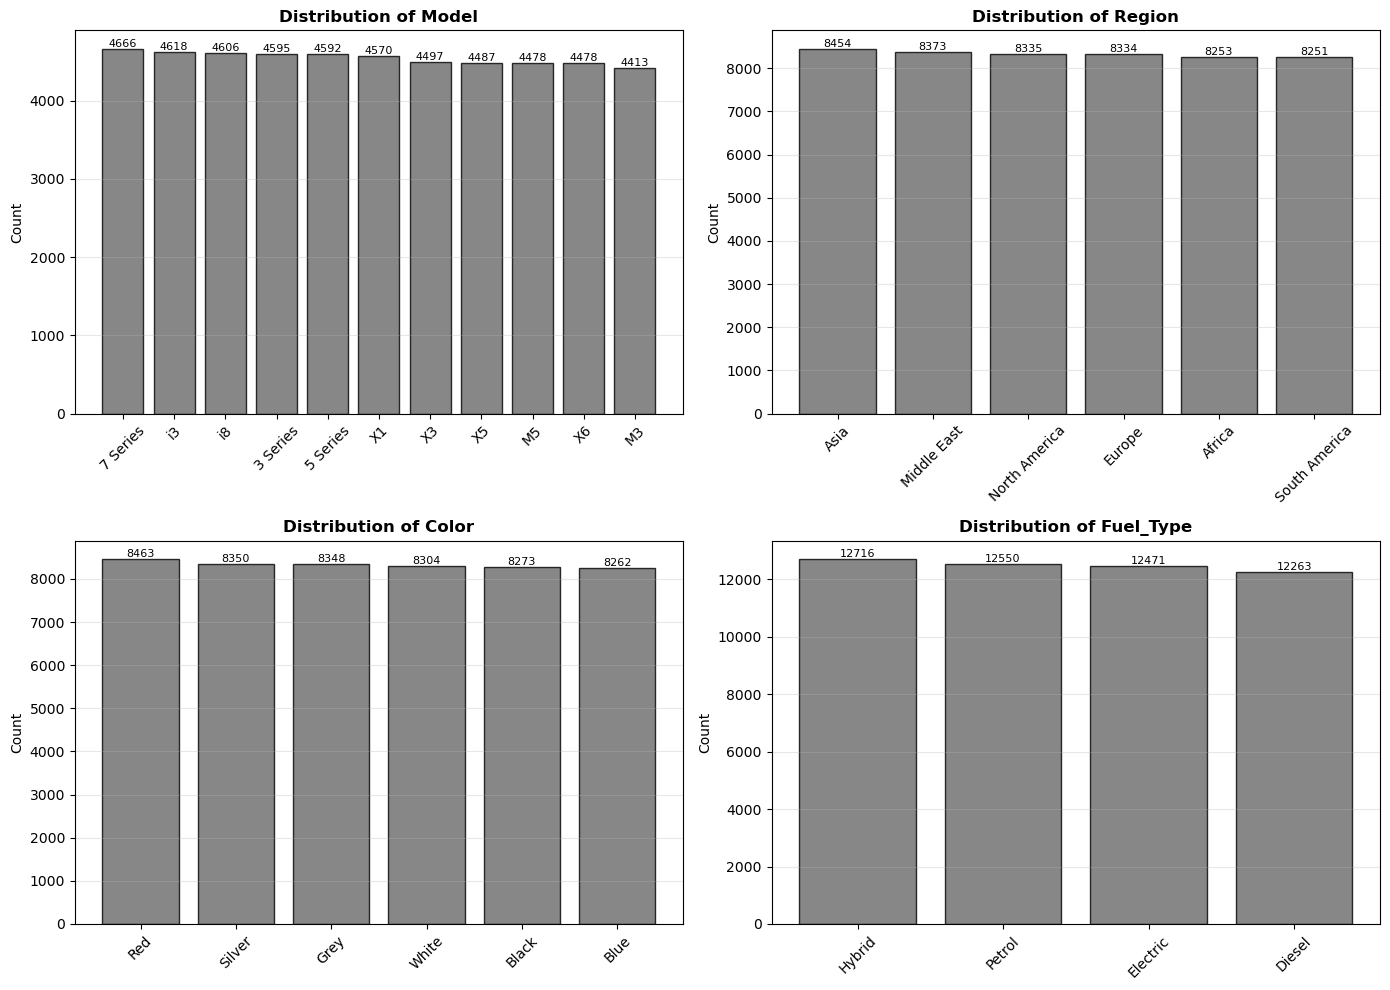

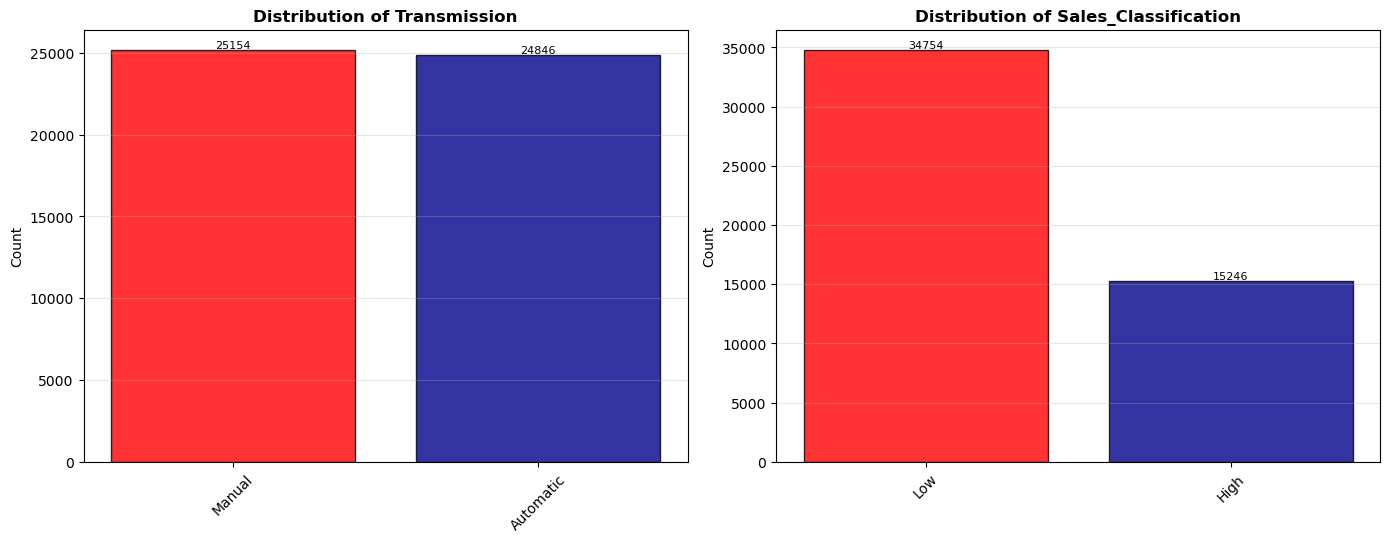

In [13]:
#  Distribution of categorical variables
print("DISTRIBUTION OF CATEGORICAL VARIABLES (COUNT)")

categorical_vars = ['Model', 'Region', 'Color',
                    'Fuel_Type', 'Transmission', 'Sales_Classification']

for i in range(0, len(categorical_vars), 4):

    subset = categorical_vars[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        if col in df.columns:

            value_counts = df[col].value_counts()
            if len(value_counts) == 2:
                colors = ['red', 'darkblue']
            else:
                colors = 'dimgray'

            bars = axes[j].bar(
                value_counts.index.astype(str),
                value_counts.values,
                color=colors,
                edgecolor='black',
                alpha=0.8
            )

            axes[j].set_title(f'Distribution of {col}', fontweight='bold')
            axes[j].set_ylabel('Count')
            axes[j].tick_params(axis='x', rotation=45)
            axes[j].grid(axis='y', alpha=0.3)

            for bar in bars:
                h = bar.get_height()
                axes[j].text(bar.get_x() + bar.get_width()/2,
                             h,
                             f'{int(h)}',
                             ha='center',
                             va='bottom',
                             fontsize=8)

    for k in range(len(subset), 4):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

CATEGORICAL VARIABLES vs SALES_VOLUME (AVG)


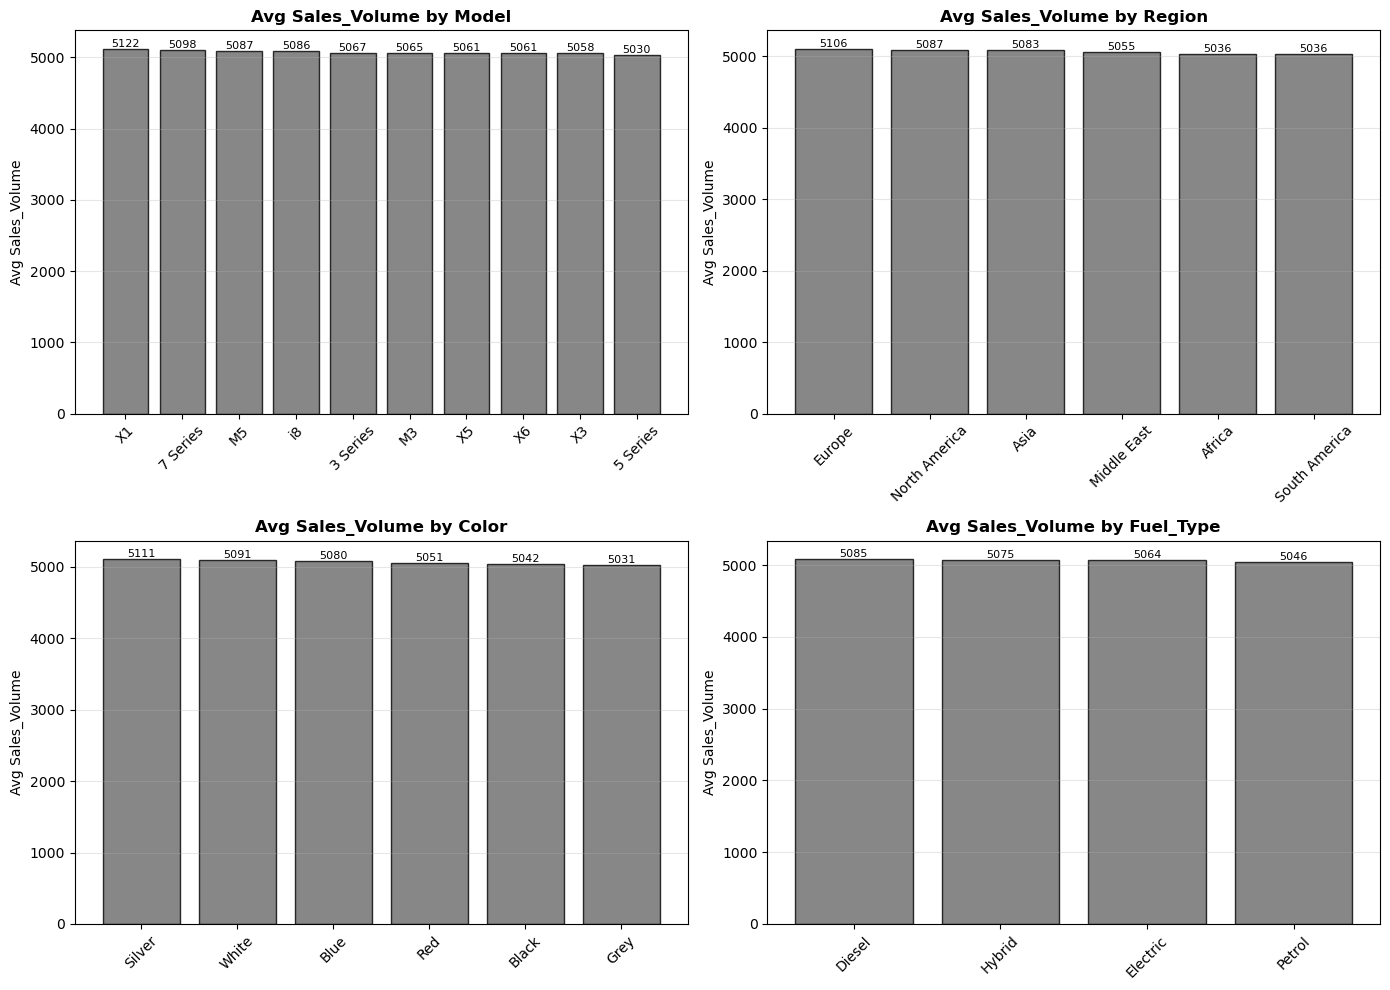

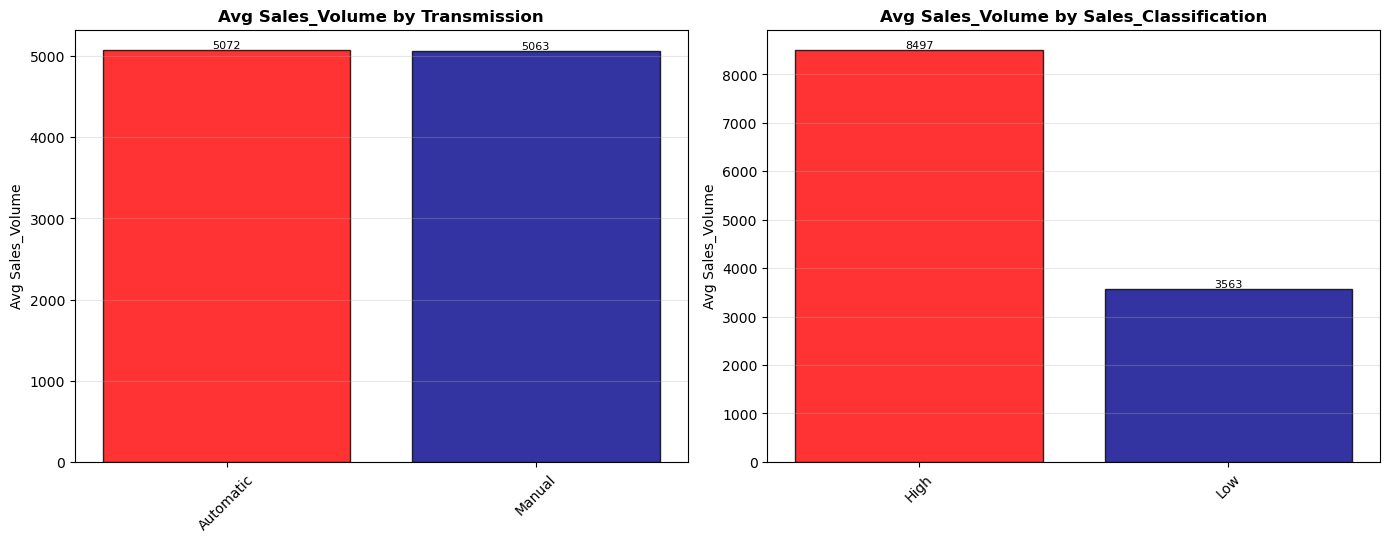

In [14]:
# Impact of categorical variables on the outcome variable
print("CATEGORICAL VARIABLES vs SALES_VOLUME (AVG)")

categorical_vars = ['Model', 'Region', 'Color',
                    'Fuel_Type', 'Transmission', 'Sales_Classification']

for i in range(0, len(categorical_vars), 4):

    subset = categorical_vars[i:i+4]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for j, col in enumerate(subset):
        if col in df.columns:

            grouped = (
                df.groupby(col)['Sales_Volume']
                  .mean()
                  .sort_values(ascending=False)
            )

            if len(grouped) > 10:
                grouped = grouped.head(10)

            # ONLY binary gets red/blue
            if len(grouped) == 2:
                colors = ['red', 'darkblue']
            else:
                colors = 'dimgray'

            bars = axes[j].bar(
                grouped.index.astype(str),
                grouped.values,
                color=colors,
                edgecolor='black',
                alpha=0.8
            )

            axes[j].set_title(f'Avg Sales_Volume by {col}', fontweight='bold')
            axes[j].set_ylabel('Avg Sales_Volume')
            axes[j].tick_params(axis='x', rotation=45)
            axes[j].grid(axis='y', alpha=0.3)

            for bar in bars:
                h = bar.get_height()
                axes[j].text(bar.get_x() + bar.get_width()/2,
                             h,
                             f'{h:.0f}',
                             ha='center',
                             va='bottom',
                             fontsize=8)

    for k in range(len(subset), 4):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()

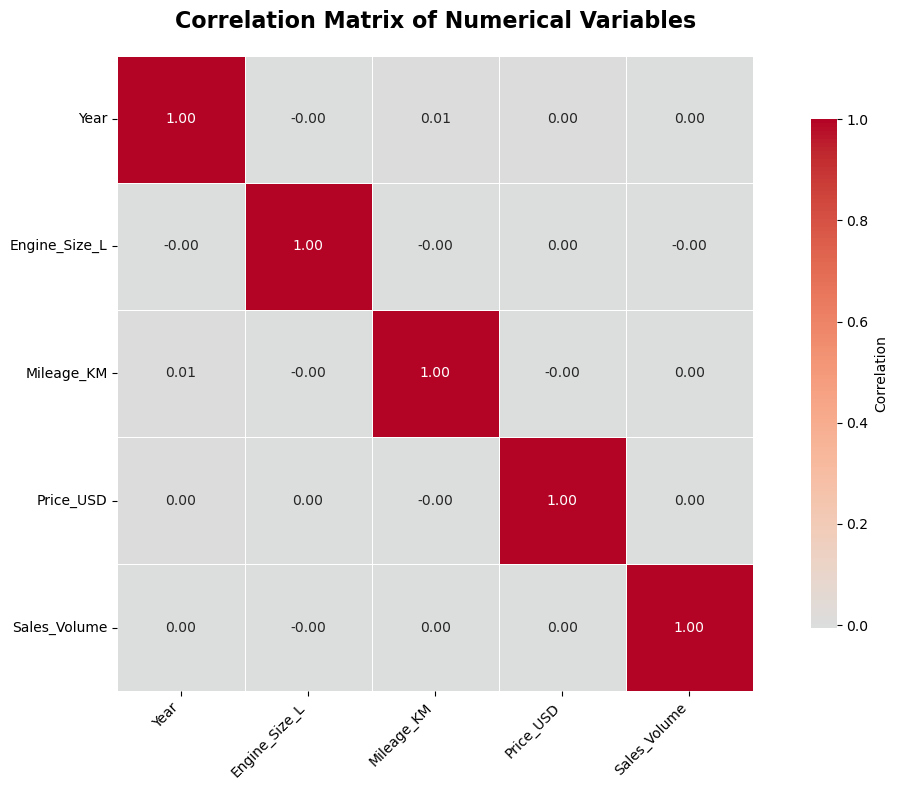

In [15]:
# Correlation heatmap
correlation_data = df[numerical_vars].corr()

plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    correlation_data, annot=True,
    cmap="coolwarm", center=0,  # blue = negative, red = positive
    square=True, fmt=".2f",
    linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

ax.set_title("Correlation Matrix of Numerical Variables",
             fontsize=16, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## III. Data Preprocessing

In [16]:
# Convert categorical variables to numerical using dummy variables

categorical_to_encode = ['Model', 'Region', 'Color',
                         'Fuel_Type', 'Transmission', 'Sales_Classification']

df_encoded = df.copy()   

# Create dummy variables for all categorical variables
for col in categorical_to_encode:
    if col in df_encoded.columns:
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        df_encoded.drop(col, axis=1, inplace=True)

print("All categorical variables converted to dummy variables")

All categorical variables converted to dummy variables


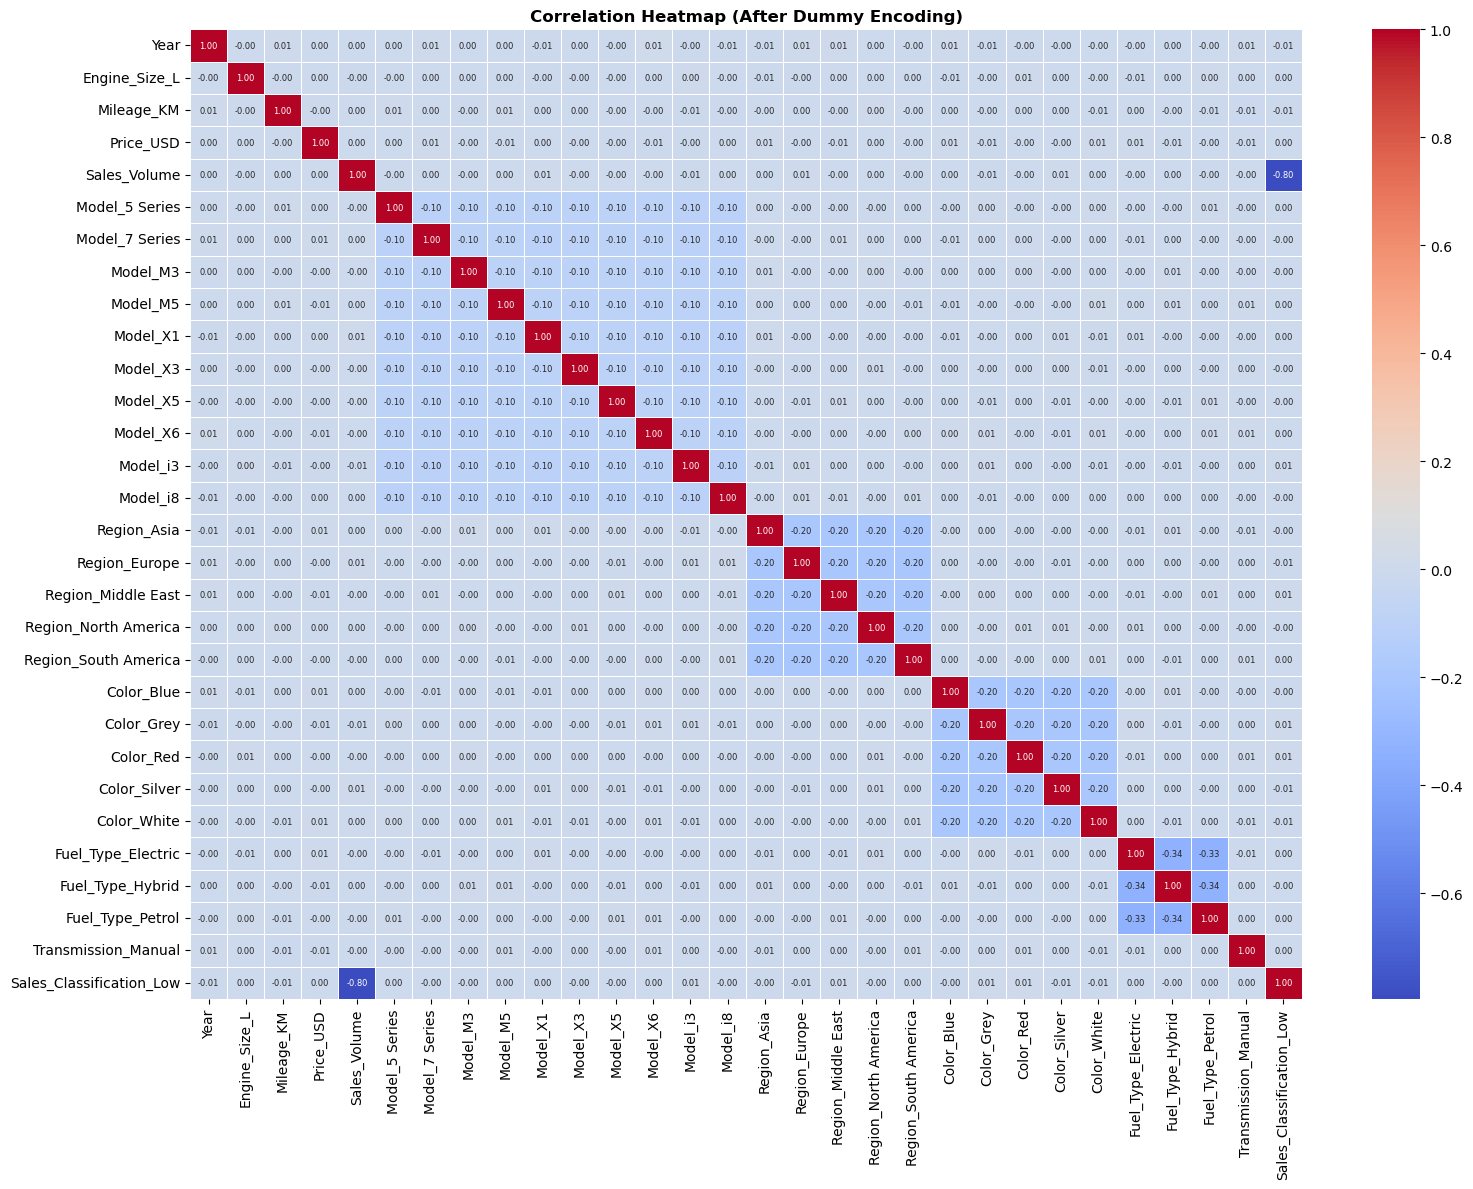

In [17]:
import seaborn as sns

# Correlation heatmap after dummy encoding (WITH numbers)
corr_encoded = df_encoded.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_encoded,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.5,
    cbar=True
)

plt.title("Correlation Heatmap (After Dummy Encoding)", fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Variable Selection
features_to_drop = ['Sales_Classification_Low']

X = df_encoded.drop(features_to_drop + ['Sales_Volume'], axis=1, errors='ignore')
y = df_encoded['Sales_Volume']

print(f"Final feature set shape: {X.shape}")
print(f"Target variable shape: {y.shape}")

Final feature set shape: (50000, 28)
Target variable shape: (50000,)


### Data Partitioning

In [19]:
# Split data set into 80% training and 20% test set

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set: 40000 samples
Test set: 10000 samples
Number of features: 28


In [20]:
# Standardize the sets
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

train_X_std = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

test_X_std = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## Polynomial Regression

### Degree Selection

Best Polynomial Degree: 1


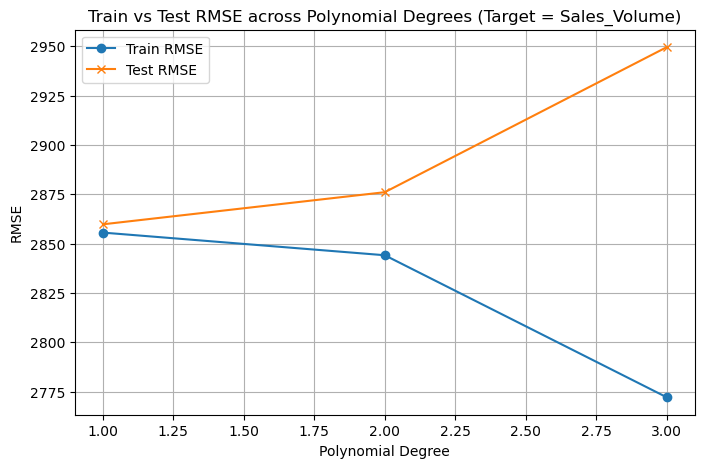

In [21]:
train_mse_list = []
test_mse_list = []
train_rmse_list = []
test_rmse_list = []

degrees = range(1, 4)  

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(train_X_std)
    X_test_poly = poly.transform(test_X_std)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # Append results for plotting
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)
    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

# Find the best degree for TV
best_degree = degrees[np.argmin(test_rmse_list)]
print(f'Best Polynomial Degree: {best_degree}')

# Plot after loop
plt.figure(figsize=(8,5))
plt.plot(list(degrees), train_rmse_list, marker='o', label="Train RMSE")
plt.plot(list(degrees), test_rmse_list, marker='x', label="Test RMSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Train vs Test RMSE across Polynomial Degrees (Target = Sales_Volume)")
plt.grid(True)
plt.legend()
plt.show()


In [22]:
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score (y_train, y_train_pred)
test_r2 = r2_score (y_test, y_test_pred)
results = pd.DataFrame({
    "Degree": list(degrees),
    "Train_MAE": train_mae,
    "Test_MAE": test_mae,
    "Train_RMSE": train_rmse,
    "Test_RMSE": test_rmse,
    "Train_R2": train_r2,
    "Test_R2": test_r2
})

display(results)

,Degree,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE,Train_R2,Test_R2
0,1,2376.419724,2531.806487,2772.204037,2949.458589,0.058008,-0.064616
1,2,2376.419724,2531.806487,2772.204037,2949.458589,0.058008,-0.064616
2,3,2376.419724,2531.806487,2772.204037,2949.458589,0.058008,-0.064616


### Fit Model

In [23]:
# Train final model with best degree + residual diagnostics
# Refit polynomial transformer and model using the best degree
poly_final = PolynomialFeatures(degree=best_degree, include_bias=False)

X_train_poly_final = poly_final.fit_transform(train_X_std)
X_test_poly_final = poly_final.transform(test_X_std)

final_model = LinearRegression()
final_model.fit(X_train_poly_final, y_train)

# Final predictions
y_test_pred_final = final_model.predict(X_test_poly_final)

# Final metrics
final_mse = mean_squared_error(y_test, y_test_pred_final)
final_mae = mean_absolute_error(y_test, y_test_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_final))
final_r2 = r2_score(y_test, y_test_pred_final)

print("Final Test MSE:", final_mse)
print("Final Test MAE:", final_mae)
print("Final Test RMSE:", final_rmse)
print("Final Test R2:", final_r2)

Final Test MSE: 8178328.250205872
Final Test MAE: 2477.130817115632
Final Test RMSE: 2859.7776574772156
Final Test R2: -0.0008587258844896528


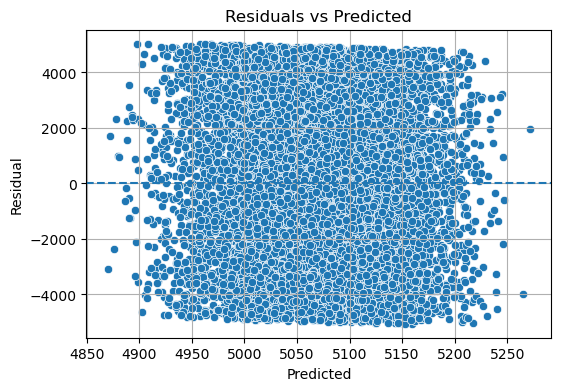

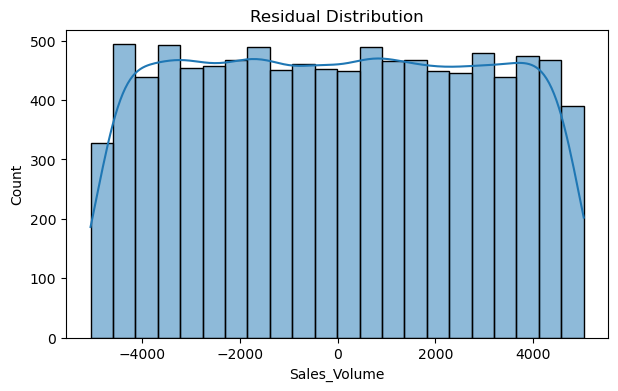

In [24]:
# Residual analysis: checks bias / heteroscedasticity patterns
residuals = y_test - y_test_pred_final

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test_pred_final, y=residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.grid(True)
plt.show()

# Residual distribution (should look somewhat symmetric)
plt.figure(figsize=(7,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

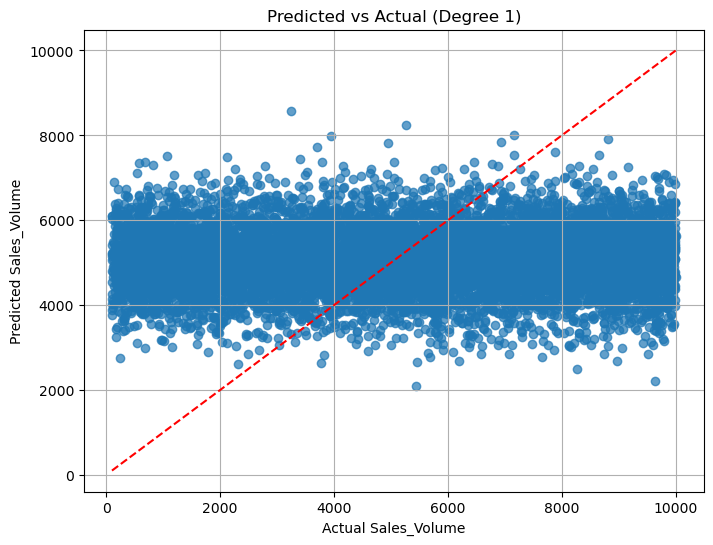

In [25]:
# Plot Predictions vs Test Data 
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')  # perfect prediction line

plt.xlabel("Actual Sales_Volume")
plt.ylabel("Predicted Sales_Volume")
plt.title(f"Predicted vs Actual (Degree {best_degree})")
plt.grid(True)
plt.show()

### Extract Feature Names + Coefficients

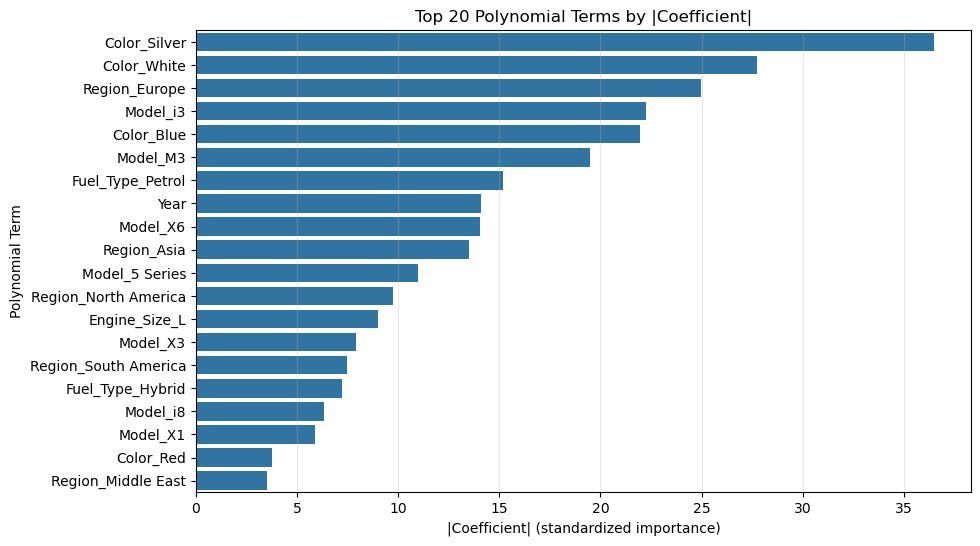

,Feature,Coefficient,Abs_Coefficient
22,Color_Silver,36.487708,36.487708
23,Color_White,27.722726,27.722726
15,Region_Europe,24.965351,24.965351
12,Model_i3,-22.231399,22.231399
19,Color_Blue,21.961540,21.961540
6,Model_M3,-19.474189,19.474189
26,Fuel_Type_Petrol,-15.168403,15.168403
0,Year,14.100205,14.100205
11,Model_X6,-14.062817,14.062817
14,Region_Asia,13.514703,13.514703


In [26]:
# 1) Get feature names from the SAME transformer used in training 
feature_names = poly_final.get_feature_names_out(train_X_std.columns)

# 2) Coefficients 
coefs = final_model.coef_
if coefs.ndim > 1:
    coefs = coefs.ravel()

# 3) Build coefficient dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

# 4) Select top N for plotting
TOP_N = 20
top_terms = coef_df.sort_values("Abs_Coefficient", ascending=False).head(TOP_N)

# 5) Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_terms, y="Feature", x="Abs_Coefficient")
plt.title(f"Top {TOP_N} Polynomial Terms by |Coefficient|")
plt.xlabel("|Coefficient| (standardized importance)")
plt.ylabel("Polynomial Term")
plt.grid(True, axis="x", alpha=0.3)
plt.show()

top_terms


## Gaussian Process Regressor (GPR)

### Evaluation Funtions

In [27]:
def calculate_metrics_std(model, train_X_std, y_train, test_X_std, y_test):

    # Predictions
    train_preds_gpr = model.predict(train_X_std)
    test_preds_gpr  = model.predict(test_X_std)

    # RMSE
    train_rmse_gpr = np.sqrt(mean_squared_error(y_train, train_preds_gpr))
    test_rmse_gpr  = np.sqrt(mean_squared_error(y_test, test_preds_gpr))

    # MAE
    train_mae_gpr = mean_absolute_error(y_train, train_preds_gpr)
    test_mae_gpr  = mean_absolute_error(y_test, test_preds_gpr)

    # R²
    train_r2_gpr = r2_score(y_train, train_preds_gpr)
    test_r2_gpr  = r2_score(y_test, test_preds_gpr)

    # Output (same layout as before)
    print("Model Evaluation (STANDARDIZED X):")
    print(f"Train R² : {train_r2_gpr:.4f}, RMSE: {train_rmse_gpr:.4f}, MAE: {train_mae_gpr:.4f}")
    print(f"Test  R² : {test_r2_gpr:.4f}, RMSE: {test_rmse_gpr:.4f}, MAE: {test_mae_gpr:.4f}")

Subsample shapes: (1000, 28) (1000,)
Training: 0) 0) DotProduct (linear-ish baseline)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


Optimized Kernel: DotProduct(sigma_0=9.33)
Model Evaluation (STANDARDIZED X):
Train R² : 0.0294, RMSE: 2826.8502, MAE: 2429.7573
Test  R² : -0.0327, RMSE: 2904.9580, MAE: 2504.6305
Training: 1) 1) DotProduct + White


/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:660: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__sigma_0 is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimized Kernel: DotProduct(sigma_0=1e+05) + WhiteKernel(noise_level=1)
Model Evaluation (STANDARDIZED X):
Train R² : 0.0293, RMSE: 2826.8959, MAE: 2429.6177
Test  R² : -0.0329, RMSE: 2905.1837, MAE: 2504.7912
Training: 2) 2) RBF (smooth only)
Optimized Kernel: RBF(length_scale=2.19)
Model Evaluation (STANDARDIZED X):
Train R² : 1.0000, RMSE: 0.0000, MAE: 0.0000
Test  R² : -0.4252, RMSE: 3412.6216, MAE: 2826.6019
Training: 3) 3) C * RBF (amplitude + smooth)


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimized Kernel: 10**2 * Matern(length_scale=2.1, nu=2.5) + WhiteKernel(noise_level=1)
Model Evaluation (STANDARDIZED X):
Train R² : 0.9998, RMSE: 42.8765, MAE: 33.8364
Test  R² : -0.2281, RMSE: 3167.8806, MAE: 2668.0541
Training: 7) 7) C * RationalQuadratic + White


/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Optimized Kernel: 10**2 * RationalQuadratic(alpha=0.105, length_scale=1e-05) + WhiteKernel(noise_level=1)
Model Evaluation (STANDARDIZED X):
Train R² : 0.9999, RMSE: 29.9844, MAE: 25.8426
Test  R² : -0.0103, RMSE: 2873.2407, MAE: 2485.3699


,train_mae_gpr,train_rmse_gpr,train_r2_gpr,test_mae_gpr,test_rmse_gpr,test_r2_gpr,Optimized_Kernel
Kernel_Name,,,,,,,
0) DotProduct (linear-ish baseline),2.429757e+03,2.826850e+03,0.029379,2504.630550,2904.957976,-0.032733,DotProduct(sigma_0=9.33)
1) DotProduct + White,2.429618e+03,2.826896e+03,0.029348,2504.791241,2905.183745,-0.032893,DotProduct(sigma_0=1e+05) + WhiteKernel(noise_...
2) RBF (smooth only),4.181752e-07,6.033010e-07,1.000000,2826.601906,3412.621623,-0.425229,RBF(length_scale=2.19)
3) C * RBF (amplitude + smooth),4.181796e-09,6.032468e-09,1.000000,2826.601799,3412.621441,-0.425228,10**2 * RBF(length_scale=2.19)
4) C * RBF + White (recommended baseline),4.106873e+01,5.677343e+01,0.999608,2820.335332,3402.873457,-0.417098,10**2 * RBF(length_scale=2.2) + WhiteKernel(no...
5) C * Matern(nu=1.5) + White,3.212458e+01,3.923771e+01,0.999813,2633.363945,3111.617545,-0.184897,"10**2 * Matern(length_scale=2.06, nu=1.5) + Wh..."
6) C * Matern(nu=2.5) + White,3.383635e+01,4.287651e+01,0.999777,2668.054136,3167.880644,-0.228134,"10**2 * Matern(length_scale=2.1, nu=2.5) + Whi..."
7) C * RationalQuadratic + White,2.584257e+01,2.998439e+01,0.999891,2485.369942,2873.240713,-0.010304,"10**2 * RationalQuadratic(alpha=0.105, length_..."


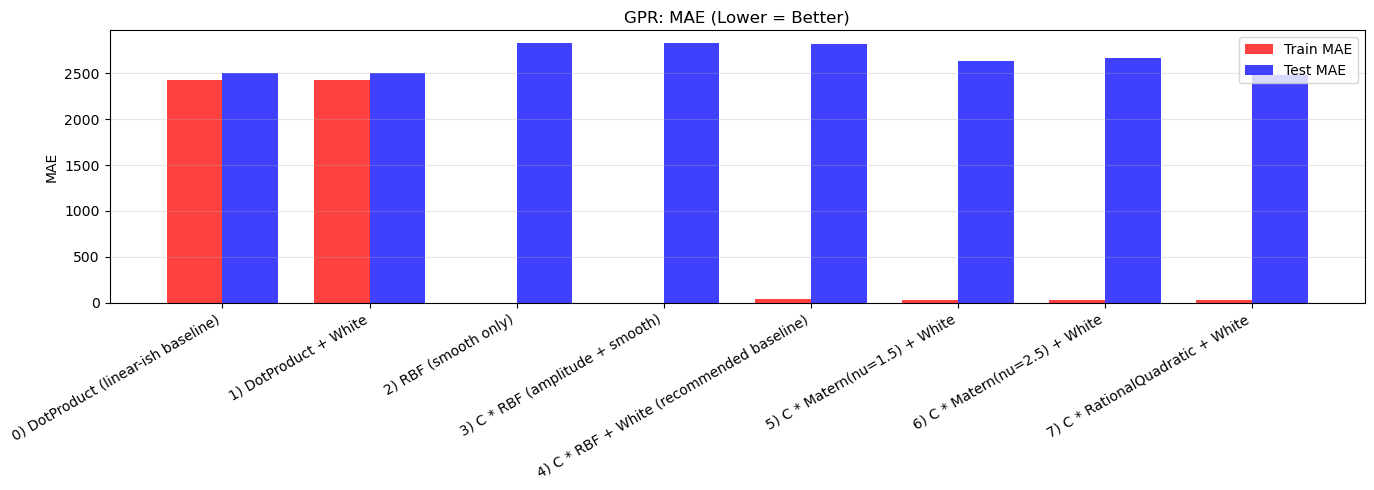

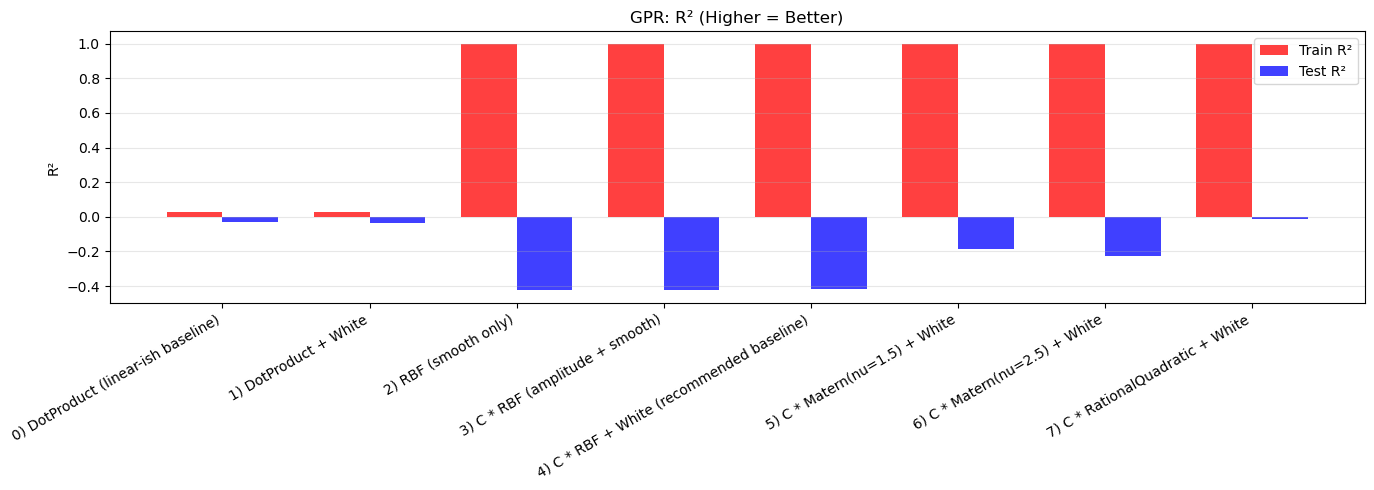

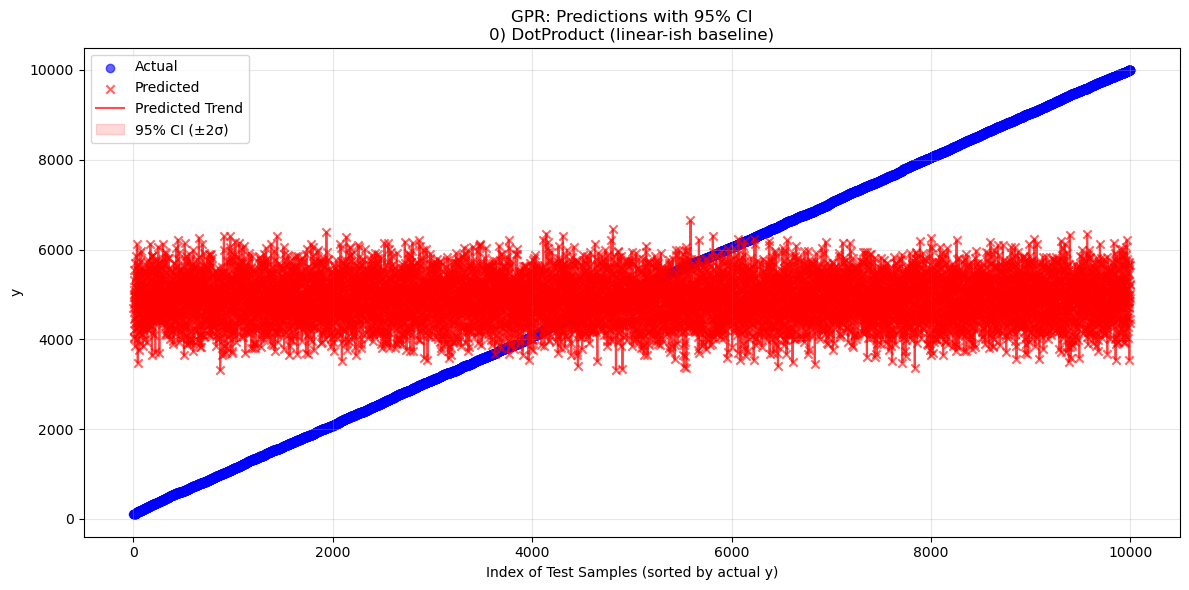

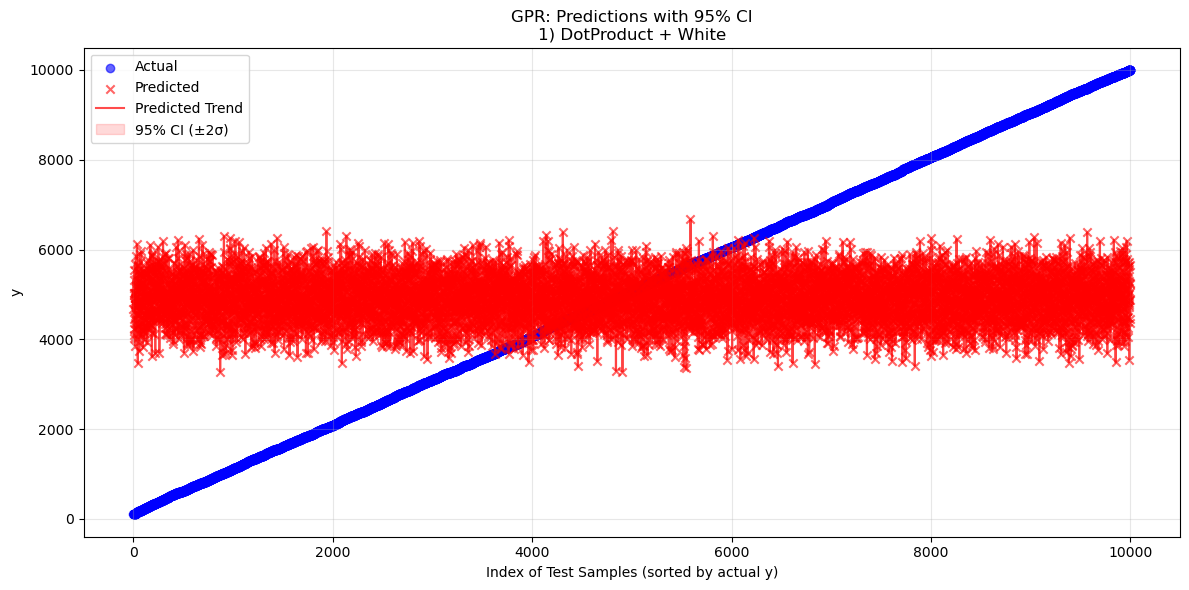

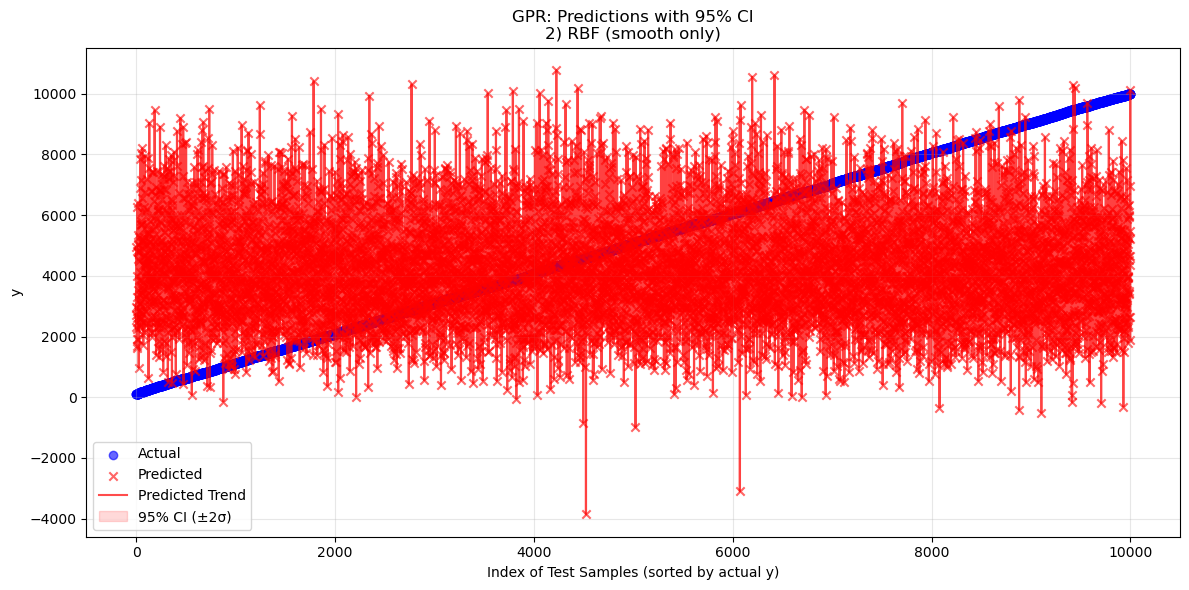

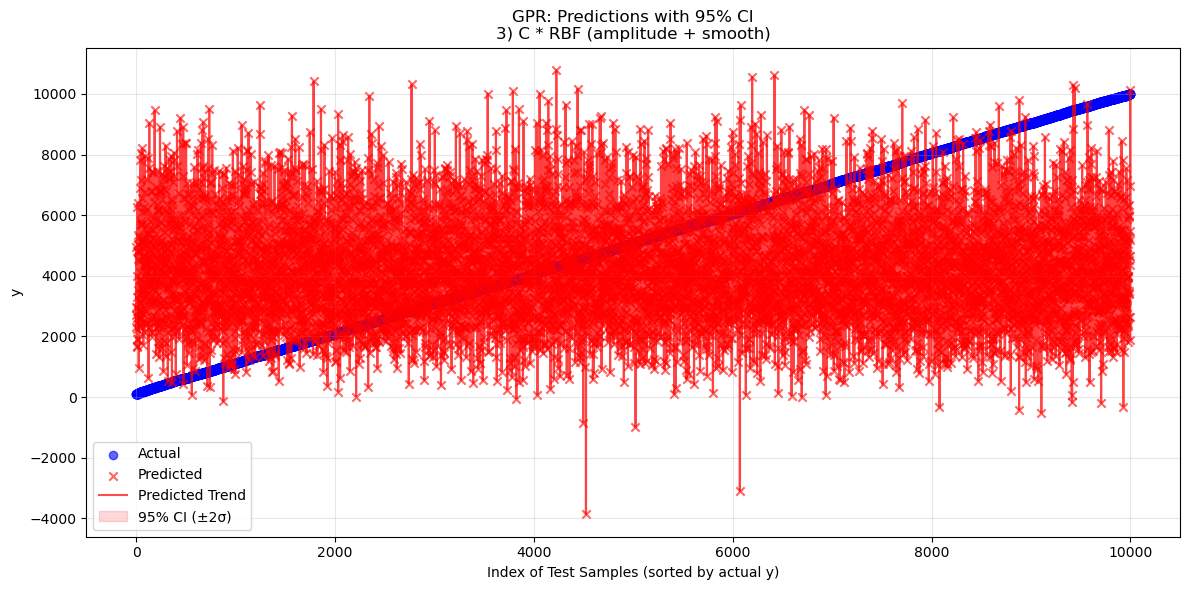

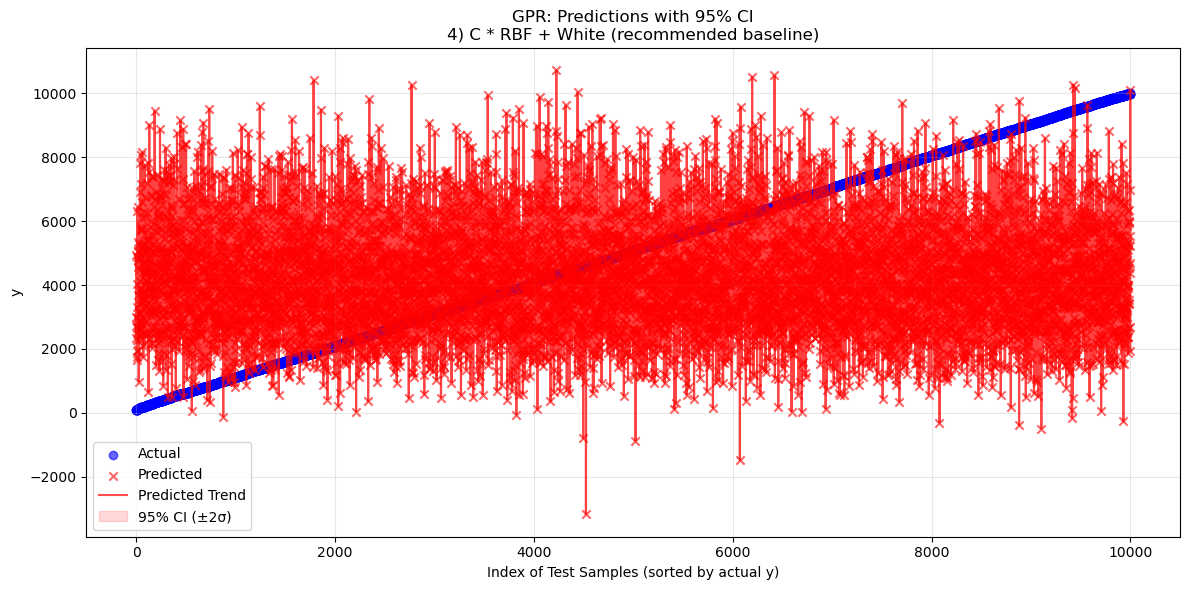

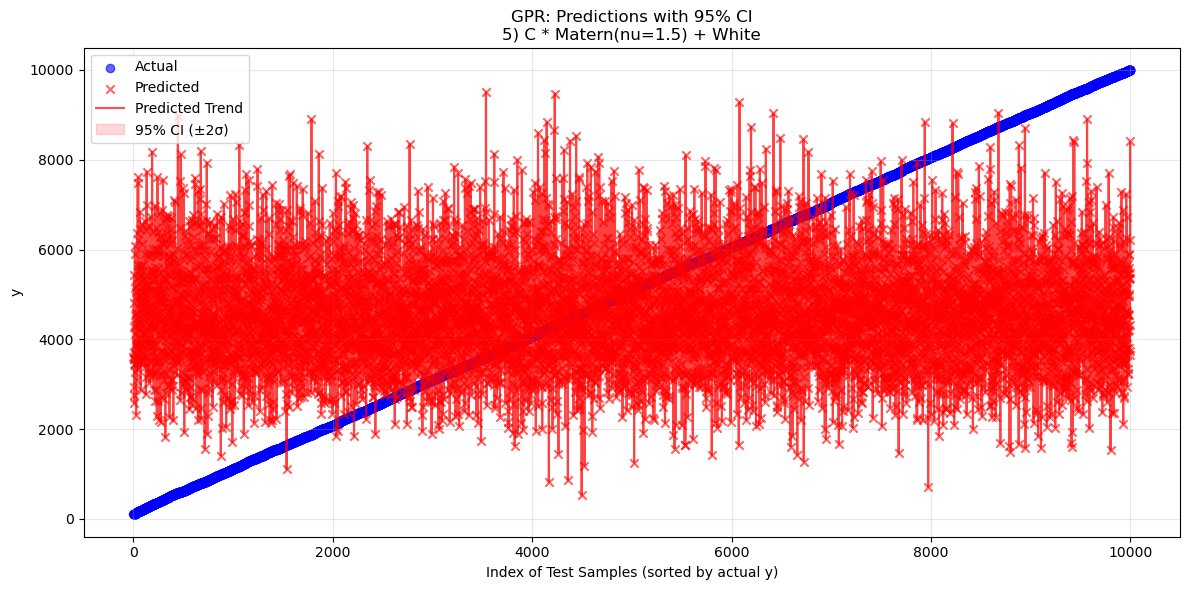

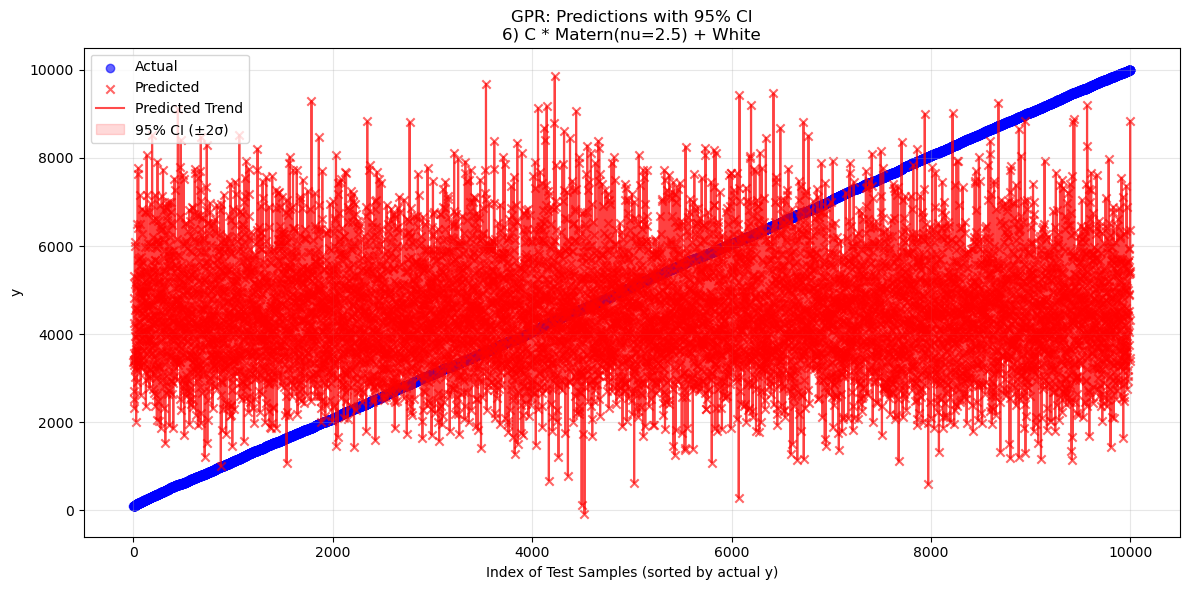

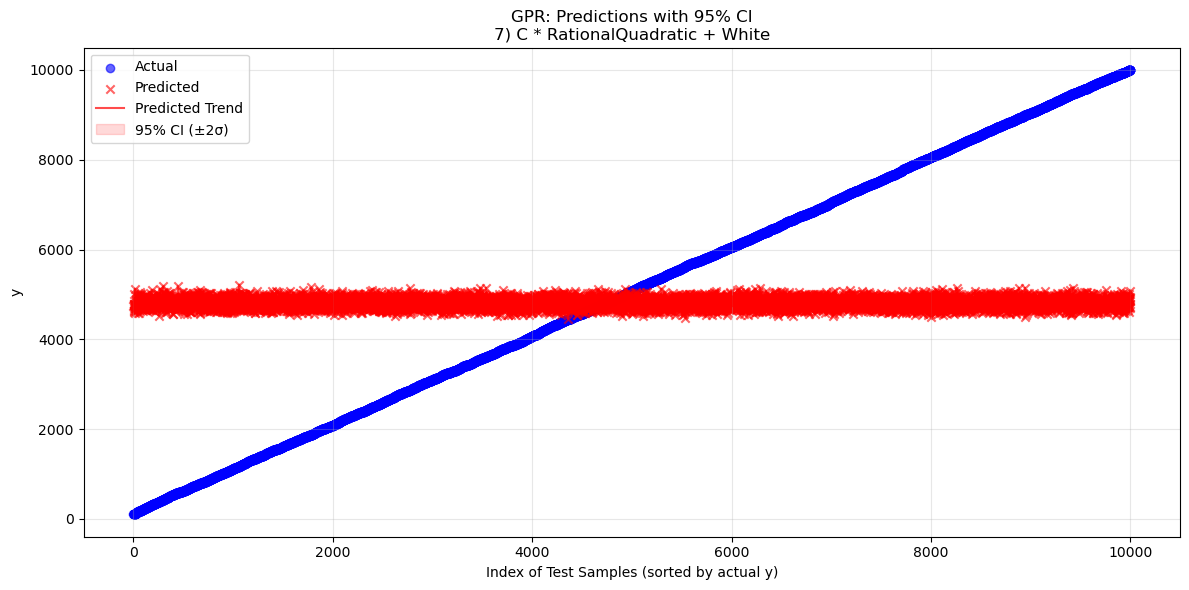

In [28]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, DotProduct,
    ConstantKernel as C, WhiteKernel
)
import numpy as np
import pandas as pd

# for plots and metrics table 
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def eval_gpr_train_test(model, X_train, y_train, X_test, y_test):
    yhat_train = model.predict(X_train)
    yhat_test  = model.predict(X_test)

    return {
        "train_mae_gpr": mean_absolute_error(y_train, yhat_train),
        "train_rmse_gpr": np.sqrt(mean_squared_error(y_train, yhat_train)),
        "train_r2_gpr": r2_score(y_train, yhat_train),
        "test_mae_gpr": mean_absolute_error(y_test, yhat_test),
        "test_rmse_gpr": np.sqrt(mean_squared_error(y_test, yhat_test)),
        "test_r2_gpr": r2_score(y_test, yhat_test),
    }

def plot_ci_one_kernel(model, X_test, y_test, title):
    y_pred, y_std = model.predict(X_test, return_std=True)

    order = np.argsort(np.asarray(y_test))
    y_test_s = np.asarray(y_test)[order]
    y_pred_s = np.asarray(y_pred)[order]
    y_std_s  = np.asarray(y_std)[order]

    x = np.arange(len(y_test_s))
    lower = y_pred_s - 2 * y_std_s
    upper = y_pred_s + 2 * y_std_s

    plt.figure(figsize=(12, 6))
    plt.scatter(x, y_test_s, label="Actual", marker="o", alpha=0.6, color="blue")
    plt.scatter(x, y_pred_s, label="Predicted", marker="x", alpha=0.6, color="red")
    plt.plot(x, y_pred_s, alpha=0.7, color="red", label="Predicted Trend")
    plt.fill_between(x, lower, upper, alpha=0.15, color="red", label="95% CI (±2σ)")

    plt.title(title)
    plt.xlabel("Index of Test Samples (sorted by actual y)")
    plt.ylabel("y")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_kernel_bars(metrics_df, title_prefix="GPR"):
    labels = metrics_df.index.tolist()
    x = np.arange(len(labels))
    width = 0.38

    # MAE
    plt.figure(figsize=(14, 5))
    plt.bar(x - width/2, metrics_df["train_mae_gpr"], width, label="Train MAE", color="red", alpha=0.75)
    plt.bar(x + width/2, metrics_df["test_mae_gpr"],  width, label="Test MAE",  color="blue", alpha=0.75)
    plt.title(f"{title_prefix}: MAE (Lower = Better)")
    plt.ylabel("MAE")
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # R²
    plt.figure(figsize=(14, 5))
    plt.bar(x - width/2, metrics_df["train_r2_gpr"], width, label="Train R²", color="red", alpha=0.75)
    plt.bar(x + width/2, metrics_df["test_r2_gpr"],  width, label="Test R²",  color="blue", alpha=0.75)
    plt.title(f"{title_prefix}: R² (Higher = Better)")
    plt.ylabel("R²")
    plt.xticks(x, labels, rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 1) Subsample TRAIN 
sample_n = 1000
train_sub_X = train_X_std.sample(n=sample_n, random_state=42)
train_sub_y = y_train.loc[train_sub_X.index] if hasattr(y_train, "loc") else y_train[train_sub_X.index]

print("Subsample shapes:", train_sub_X.shape, train_sub_y.shape)

# 2) Kernel bounds
LS_BOUNDS = (1e-2, 1e2)     # length scale bounds
C_BOUNDS  = (1e-2, 1e2)     # constant/amplitude bounds
NOISE_BOUNDS = (1e-6, 1e0)  # noise bounds


# 3) Kernels
kernels = {
    "0) DotProduct (linear-ish baseline)":
        DotProduct(),

    "1) DotProduct + White":
        DotProduct() + WhiteKernel(noise_level=1.0, noise_level_bounds=NOISE_BOUNDS),

    "2) RBF (smooth only)":
        RBF(length_scale=1.0, length_scale_bounds=LS_BOUNDS),

    "3) C * RBF (amplitude + smooth)":
        C(1.0, C_BOUNDS) * RBF(length_scale=1.0, length_scale_bounds=LS_BOUNDS),

    "4) C * RBF + White (recommended baseline)":
        C(1.0, C_BOUNDS) * RBF(length_scale=1.0, length_scale_bounds=LS_BOUNDS)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=NOISE_BOUNDS),

    "5) C * Matern(nu=1.5) + White":
        C(1.0, C_BOUNDS) * Matern(length_scale=1.0, length_scale_bounds=LS_BOUNDS, nu=1.5)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=NOISE_BOUNDS),

    "6) C * Matern(nu=2.5) + White":
        C(1.0, C_BOUNDS) * Matern(length_scale=1.0, length_scale_bounds=LS_BOUNDS, nu=2.5)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=NOISE_BOUNDS),

    "7) C * RationalQuadratic + White":
        C(1.0, C_BOUNDS) * RationalQuadratic(length_scale=1.0, alpha=1.0)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=NOISE_BOUNDS),
}

# store trained models and metrics per kernel
trained_models = {}
metrics_rows = []

# 4) Train + Evaluate ALL kernels
results = []

for i, (name, kernel) in enumerate(kernels.items()):
    sep = "=" * 70
    print(sep)
    print(f"Training: {i}) {name}")
    print(sep)

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=10, 
        random_state=42,
        normalize_y=False
    )

    # Fit on TRAIN SUBSAMPLE
    gpr.fit(train_sub_X, train_sub_y)

    print("Optimized Kernel:", gpr.kernel_)

    calculate_metrics_std(
        gpr,
        train_sub_X, train_sub_y,
        test_X_std, y_test
    )


    trained_models[name] = gpr

    m = eval_gpr_train_test(gpr, train_sub_X, train_sub_y, test_X_std, y_test)
    m["Kernel_Name"] = name
    m["Optimized_Kernel"] = str(gpr.kernel_)
    metrics_rows.append(m)

    # Store summary
    results.append({
        "Kernel_Name": name,
        "Optimized_Kernel": str(gpr.kernel_)
    })

# 5) Summary table
results_df = pd.DataFrame(results)
results_df

metrics_df = pd.DataFrame(metrics_rows).set_index("Kernel_Name")
display(metrics_df)

plot_kernel_bars(metrics_df, title_prefix="GPR")

top_kernels = metrics_df.index.tolist()

for kname in top_kernels:
    model = trained_models[kname]
    plot_ci_one_kernel(model, test_X_std, y_test, title=f"GPR: Predictions with 95% CI\n{kname}")

## Multiple Linear Regression (MLR)

### Least Square Regression (OLS)

In [29]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(train_X_std).astype(float)
X_test_ols  = sm.add_constant(test_X_std).astype(float)

ols_model   = sm.OLS(y_train.astype(float), X_train_ols)
ols_results = ols_model.fit()

print(ols_results.summary())

                            OLS Regression Results                            
Dep. Variable:           Sales_Volume   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7098
Date:                Mon, 23 Feb 2026   Prob (F-statistic):              0.869
Time:                        23:41:22   Log-Likelihood:            -3.7504e+05
No. Observations:               40000   AIC:                         7.501e+05
Df Residuals:                   39971   BIC:                         7.504e+05
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 5066.6629 

### Model Evaluation

In [30]:
# TRAIN predictions + metrics (OLS)
y_pred_train_ols = ols_results.predict(X_train_ols)
mae_train_ols    = mean_absolute_error(y_train, y_pred_train_ols)
rmse_train_ols   = np.sqrt(mean_squared_error(y_train, y_pred_train_ols))
mse_train_ols    = mean_squared_error(y_train, y_pred_train_ols)
r2_train_ols     = r2_score(y_train, y_pred_train_ols)

n_train_ols, p_ols = train_X_std.shape
adj_r2_train_ols = 1 - (1 - r2_train_ols) * (n_train_ols - 1) / (n_train_ols - p_ols - 1)

# TEST predictions + metrics (OLS)
y_pred_test_ols = ols_results.predict(X_test_ols)
mae_test_ols    = mean_absolute_error(y_test, y_pred_test_ols)
rmse_test_ols   = np.sqrt(mean_squared_error(y_test, y_pred_test_ols))
mse_test_ols    = mean_squared_error(y_test, y_pred_test_ols)
r2_test_ols     = r2_score(y_test, y_pred_test_ols)

n_test_ols = test_X_std.shape[0]
adj_r2_test_ols = 1 - (1 - r2_test_ols) * (n_test_ols - 1) / (n_test_ols - p_ols - 1)

# Metrics table
metrics_ols_df = pd.DataFrame({
    'Metric'         : ['MAE', 'RMSE', 'MSE', 'R²', 'Adjusted R²'],
    'Training Value' : [mae_train_ols, rmse_train_ols, mse_train_ols, r2_train_ols, adj_r2_train_ols],
    'Test Value'     : [mae_test_ols,  rmse_test_ols,  mse_test_ols,  r2_test_ols,  adj_r2_test_ols]
})

display(metrics_ols_df.style.format({'Training Value': '{:.4f}', 'Test Value': '{:.4f}'}))

,Metric,Training Value,Test Value
0,MAE,2469.7984,2477.1308
1,RMSE,2855.5749,2859.7777
2,MSE,8154308.2628,8178328.2502
3,R²,0.0005,-0.0009
4,Adjusted R²,-0.0002,-0.0037


In [32]:
# Compare true vs predicted values 
comparison_df = pd.DataFrame({
    'True Sales Volume'     : y_test.values,
    'Predicted Sales Volume': y_pred_test_ols.values
})
print(comparison_df.head(10))

   True Sales Volume  Predicted Sales Volume
0               4092             5003.342365
1               4207             5043.572298
2               3507             5095.314675
3               2745             5123.758917
4               1337             5122.771908
5               1480             4975.586164
6               1319             5115.292431
7               5367             5023.636137
8               3045             4922.909105
9               3522             5009.654870


### Coefficients

In [33]:
coef_df = pd.DataFrame({
    'Feature'    : ols_results.params.index,
    'Coefficient': ols_results.params.values,
    'p-value'    : ols_results.pvalues.values,
    'Significant': ols_results.pvalues.values < 0.05
}).sort_values('Coefficient', key=abs, ascending=False)

top20 = coef_df.head(20)

display(
    top20.style
    .format({'Coefficient': '{:.4f}', 'p-value': '{:.4f}'})
    .apply(lambda col: ['background-color: #d4edda' if v else ''
                        for v in top20['Significant']], subset=['Coefficient'])
)

print(f'\nTotal predictors                         : {len(coef_df) - 1}')
print(f'Statistically significant (p < 0.05)     : {coef_df[coef_df["Significant"]].shape[0]}')


,Feature,Coefficient,p-value,Significant
0,const,5066.6629,0.0000,True
23,Color_Silver,36.4877,0.0480,True
24,Color_White,27.7227,0.1330,False
16,Region_Europe,24.9654,0.1769,False
13,Model_i3,-22.2314,0.2481,False
20,Color_Blue,21.9615,0.2332,False
7,Model_M3,-19.4742,0.3070,False
27,Fuel_Type_Petrol,-15.1684,0.3881,False
1,Year,14.1002,0.3237,False
12,Model_X6,-14.0628,0.4624,False



Total predictors                         : 28
Statistically significant (p < 0.05)     : 2


### Multicollinearity Check (VIF)

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF on training set
X_vif = train_X_std.copy()

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i) 
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('Top 20 BMW predictors by VIF (higher = more multicollinearity):')
display(
    vif_data.head(20).style
    .format({'VIF': '{:.2f}'})
    .apply(lambda col: ['background-color: #f8d7da' if v > 10 else
                        'background-color: #fff3cd' if v > 5 else ''
                        for v in vif_data.head(20)['VIF']], subset=['VIF'])
)

high_vif = vif_data[vif_data['VIF'] > 10]
print(f'\nBMW features with VIF > 10 (multicollinearity concern) : {len(high_vif)}')
print(f'BMW features with VIF > 5  (moderate concern)          : {len(vif_data[vif_data["VIF"] > 5])}')
print(f'BMW features with VIF ≤ 5  (acceptable)                : {len(vif_data[vif_data["VIF"] <= 5])}')


Top 20 BMW predictors by VIF (higher = more multicollinearity):


,Feature,VIF
5,Model_7 Series,1.82
13,Model_i8,1.82
12,Model_i3,1.82
4,Model_5 Series,1.81
8,Model_X1,1.80
9,Model_X3,1.80
11,Model_X6,1.80
7,Model_M5,1.79
10,Model_X5,1.79
6,Model_M3,1.78



BMW features with VIF > 10 (multicollinearity concern) : 0
BMW features with VIF > 5  (moderate concern)          : 0
BMW features with VIF ≤ 5  (acceptable)                : 28


### Predicted vs Actual & Residual Plot

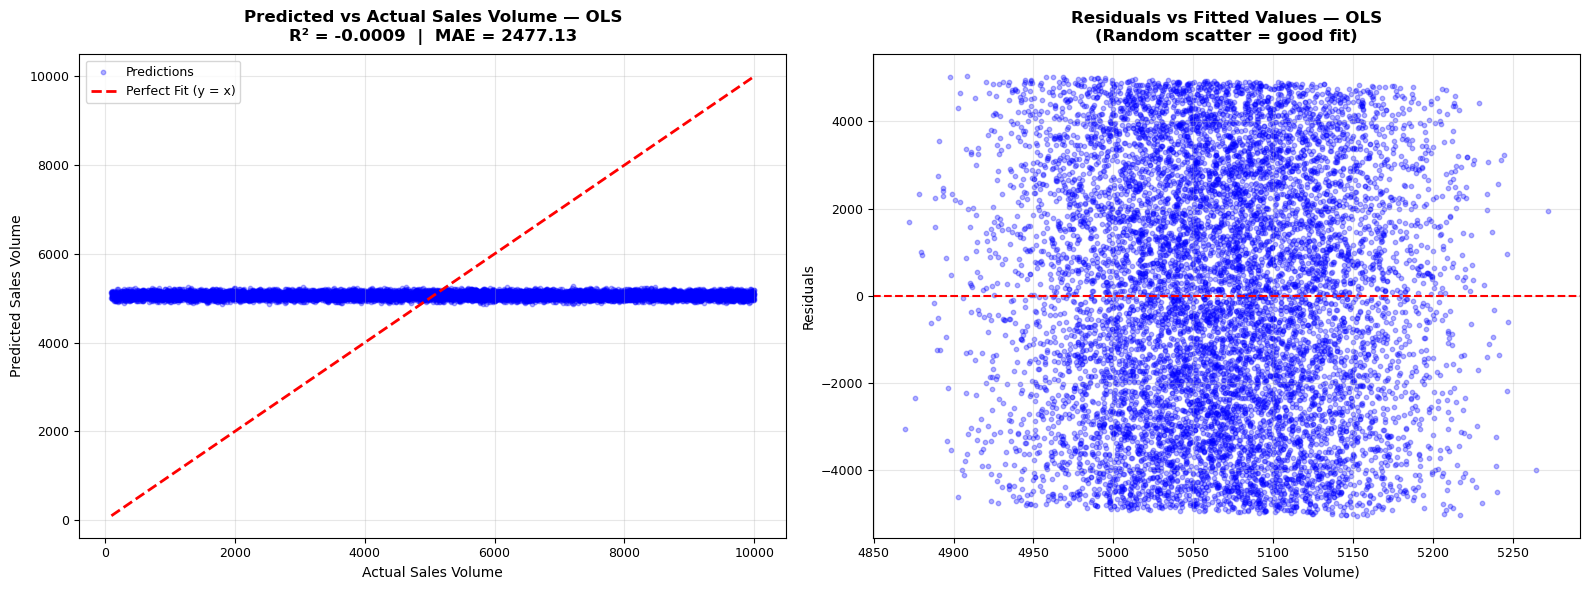

In [36]:
import matplotlib.pyplot as plt

def simple_style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.3)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Predicted vs Actual — OLS
simple_style(
    axes[0],
    title=f'Predicted vs Actual Sales Volume — OLS\nR² = {r2_test_ols:.4f}  |  MAE = {mae_test_ols:.2f}',
    xlabel='Actual Sales Volume',
    ylabel='Predicted Sales Volume'
)

axes[0].scatter(y_test, y_pred_test_ols, alpha=0.3, color='blue', s=10, label='Predictions')

lims = [
    min(y_test.min(), y_pred_test_ols.min()),
    max(y_test.max(), y_pred_test_ols.max())
]

axes[0].plot(lims, lims, color='red', linewidth=2, linestyle='--', label='Perfect Fit (y = x)')
axes[0].legend(fontsize=9)


# Residuals vs Fitted — OLS
residuals = y_test.values - y_pred_test_ols.values

simple_style(
    axes[1],
    title='Residuals vs Fitted Values — OLS\n(Random scatter = good fit)',
    xlabel='Fitted Values (Predicted Sales Volume)',
    ylabel='Residuals'
)

axes[1].scatter(y_pred_test_ols, residuals, alpha=0.3, color='blue', s=10)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

### Residual Diagnostics

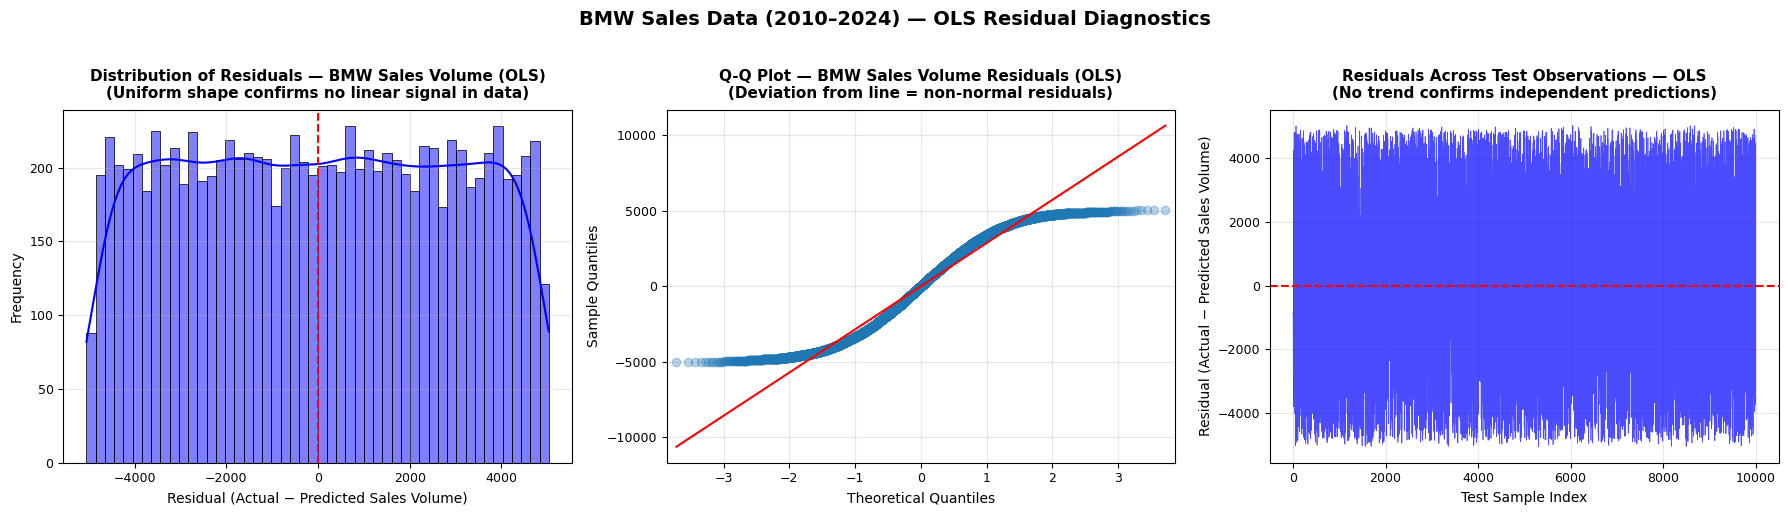

In [37]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
fig.suptitle('BMW Sales Data (2010–2024) — OLS Residual Diagnostics',
             fontsize=14, fontweight='bold', y=1.02)

# Simple style function
def simple_style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.3)


# 1) Distribution of Residuals
simple_style(
    axes[0],
    title='Distribution of Residuals — BMW Sales Volume (OLS)\n(Uniform shape confirms no linear signal in data)',
    xlabel='Residual (Actual − Predicted Sales Volume)',
    ylabel='Frequency'
)

sns.histplot(residuals, bins=50, kde=True, color='blue', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)


# 2) Q-Q Plot
simple_style(
    axes[1],
    title='Q-Q Plot — BMW Sales Volume Residuals (OLS)\n(Deviation from line = non-normal residuals)',
    xlabel='Theoretical Quantiles',
    ylabel='Sample Quantiles'
)

sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.3)
axes[1].get_lines()[0].set_color('blue')   # points
axes[1].get_lines()[1].set_color('red')    # reference line


# 3) Residuals over index
simple_style(
    axes[2],
    title='Residuals Across Test Observations — OLS\n(No trend confirms independent predictions)',
    xlabel='Test Sample Index',
    ylabel='Residual (Actual − Predicted Sales Volume)'
)

axes[2].plot(residuals, color='blue', linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

### Feature Importance (Top 15 by |Coefficient|)

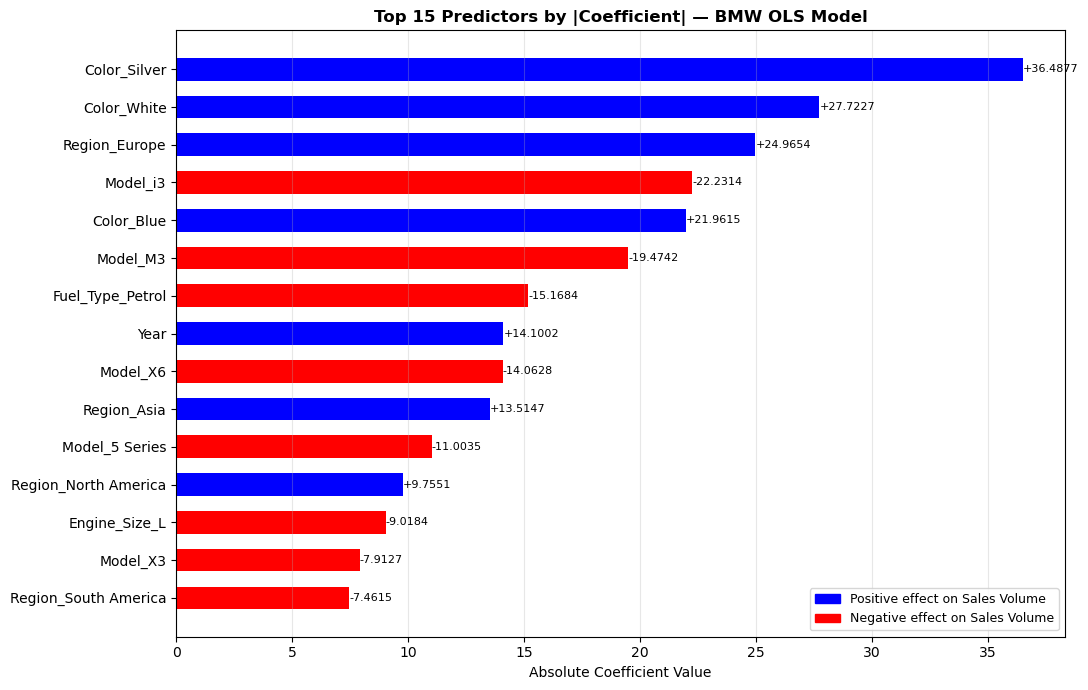

In [38]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

coef_abs = coef_df[coef_df['Feature'] != 'const'].copy()
coef_abs['Abs'] = coef_abs['Coefficient'].abs()
top15 = coef_abs.nlargest(15, 'Abs').sort_values('Abs')

# Blue = positive, Red = negative
colors = ['blue' if c > 0 else 'red' for c in top15['Coefficient']]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.barh(top15['Feature'], top15['Abs'], color=colors, height=0.6)

# Add coefficient labels
for i, (val, coef) in enumerate(zip(top15['Abs'], top15['Coefficient'])):
    ax.text(val + 0.0003, i, f'{coef:+.4f}', va='center', fontsize=8, color='black')

# Legend
pos_p = mpatches.Patch(color='blue', label='Positive effect on Sales Volume')
neg_p = mpatches.Patch(color='red', label='Negative effect on Sales Volume')
ax.legend(handles=[pos_p, neg_p], fontsize=9)

ax.set_xlabel('Absolute Coefficient Value')
ax.set_title('Top 15 Predictors by |Coefficient| — BMW OLS Model', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### PLS Regression Model (Partial Least Squares)

In [39]:
from sklearn.cross_decomposition import PLSRegression

n_components = 10
pls_model = PLSRegression(n_components=n_components)
pls_model.fit(train_X_std, y_train)

print(f'PLS model fitted with {n_components} components')
print(f'Training set : {train_X_std.shape}')
print(f'Test set     : {test_X_std.shape}')


PLS model fitted with 10 components
Training set : (40000, 28)
Test set     : (10000, 28)


### Model Evaluation (Train vs Test)

In [40]:
y_pred_pls_train = pls_model.predict(train_X_std).flatten()
y_pred_pls_test  = pls_model.predict(test_X_std).flatten()

mae_pls_train  = mean_absolute_error(y_train, y_pred_pls_train)
rmse_pls_train = np.sqrt(mean_squared_error(y_train, y_pred_pls_train))
mse_pls_train  = mean_squared_error(y_train, y_pred_pls_train)
r2_pls_train   = r2_score(y_train, y_pred_pls_train)

n_train_pls      = train_X_std.shape[0]
adj_r2_pls_train = 1 - (1 - r2_pls_train) * (n_train_pls - 1) / (n_train_pls - n_components - 1)

mae_pls_test  = mean_absolute_error(y_test, y_pred_pls_test)
rmse_pls_test = np.sqrt(mean_squared_error(y_test, y_pred_pls_test))
mse_pls_test  = mean_squared_error(y_test, y_pred_pls_test)
r2_pls_test   = r2_score(y_test, y_pred_pls_test)

n_test_pls = test_X_std.shape[0]
adj_r2_pls = 1 - (1 - r2_pls_test) * (n_test_pls - 1) / (n_test_pls - n_components - 1)

metrics_pls = pd.DataFrame({
    'Metric'         : ['MAE', 'RMSE', 'MSE', 'R²', 'Adjusted R²'],
    'Training Value' : [mae_pls_train, rmse_pls_train, mse_pls_train, r2_pls_train, adj_r2_pls_train],
    'Test Value'     : [mae_pls_test,  rmse_pls_test,  mse_pls_test,  r2_pls_test,  adj_r2_pls]
})

display(metrics_pls.style.format({'Training Value': '{:.4f}', 'Test Value': '{:.4f}'}))


,Metric,Training Value,Test Value
0,MAE,2469.7984,2477.1308
1,RMSE,2855.5749,2859.7776
2,MSE,8154308.2629,8178327.9579
3,R²,0.0005,-0.0009
4,Adjusted R²,0.0002,-0.0019


### True vs Predicted Values

In [41]:
comparison_pls = pd.DataFrame({
    'True Sales Volume'     : y_test.values.flatten(),
    'Predicted Sales Volume': y_pred_pls_test.flatten()
})
print(comparison_pls.head(10))

   True Sales Volume  Predicted Sales Volume
0               4092             5003.343734
1               4207             5043.570410
2               3507             5095.319390
3               2745             5123.749664
4               1337             5122.773831
5               1480             4975.586869
6               1319             5115.292130
7               5367             5023.637399
8               3045             4922.909748
9               3522             5009.654647


### Coefficients

In [42]:
pls_coef_df = pd.DataFrame({
    'Feature'    : train_X_std.columns,
    'Coefficient': pls_model.coef_.flatten()
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

top20_pls = pls_coef_df.head(20)

display(
    top20_pls.style
    .format({'Coefficient': '{:.4f}'})
)

print(f'\nTotal predictors : {len(pls_coef_df)}')


,Feature,Coefficient
0,Color_Silver,36.4866
1,Color_White,27.7215
2,Region_Europe,24.9678
3,Model_i3,-22.2310
4,Color_Blue,21.9598
5,Model_M3,-19.4739
6,Fuel_Type_Petrol,-15.1687
7,Year,14.0998
8,Model_X6,-14.0628
9,Region_Asia,13.5180



Total predictors : 28


### Multicollinearity Check (VIF)

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif_pls = train_X_std.copy()

vif_pls = pd.DataFrame({
    'Feature': X_vif_pls.columns,
    'VIF'    : [variance_inflation_factor(X_vif_pls.values, i)
                for i in range(X_vif_pls.shape[1])]
}).sort_values('VIF', ascending=False)

print('Top 20 BMW predictors by VIF (higher = more multicollinearity):')
display(
    vif_pls.head(20).style
    .format({'VIF': '{:.2f}'})
    .apply(lambda col: ['background-color: #f8d7da' if v > 10 else
                        'background-color: #fff3cd' if v > 5 else ''
                        for v in vif_pls.head(20)['VIF']], subset=['VIF'])
)

high_vif_pls = vif_pls[vif_pls['VIF'] > 10]
print(f'\nBMW features with VIF > 10 (multicollinearity concern) : {len(high_vif_pls)}')
print(f'BMW features with VIF > 5  (moderate concern)          : {len(vif_pls[vif_pls["VIF"] > 5])}')
print(f'BMW features with VIF ≤ 5  (acceptable)                : {len(vif_pls[vif_pls["VIF"] <= 5])}')


Top 20 BMW predictors by VIF (higher = more multicollinearity):


,Feature,VIF
5,Model_7 Series,1.82
13,Model_i8,1.82
12,Model_i3,1.82
4,Model_5 Series,1.81
8,Model_X1,1.80
9,Model_X3,1.80
11,Model_X6,1.80
7,Model_M5,1.79
10,Model_X5,1.79
6,Model_M3,1.78



BMW features with VIF > 10 (multicollinearity concern) : 0
BMW features with VIF > 5  (moderate concern)          : 0
BMW features with VIF ≤ 5  (acceptable)                : 28


### Predicted vs Actual & Residual Plot

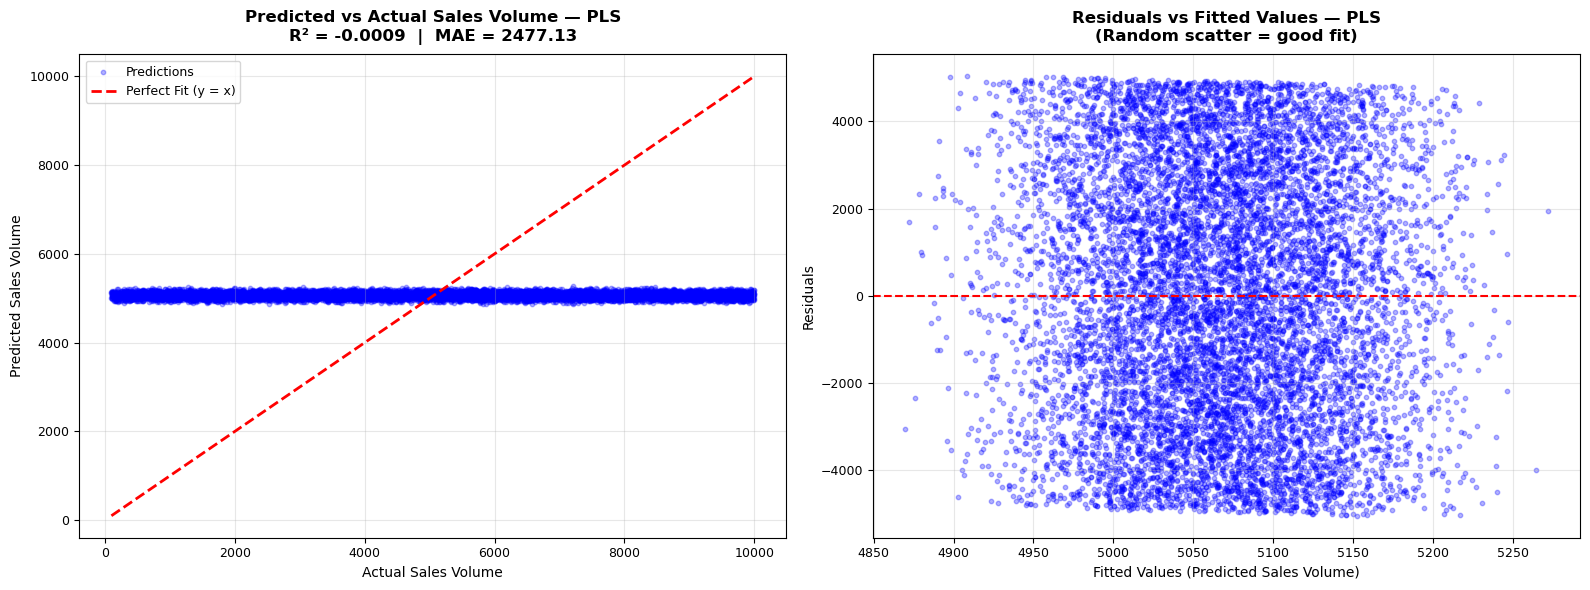

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# Simple style helper
def simple_style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.3)


# Predicted vs Actual — PLS
simple_style(
    axes[0],
    title=f'Predicted vs Actual Sales Volume — PLS\nR² = {r2_pls_test:.4f}  |  MAE = {mae_pls_test:.2f}',
    xlabel='Actual Sales Volume',
    ylabel='Predicted Sales Volume'
)

axes[0].scatter(y_test, y_pred_pls_test, alpha=0.3, color='blue', s=10, label='Predictions')

lims_pls = [
    min(y_test.min(), y_pred_pls_test.min()),
    max(y_test.max(), y_pred_pls_test.max())
]

axes[0].plot(lims_pls, lims_pls, color='red', linewidth=2, linestyle='--', label='Perfect Fit (y = x)')
axes[0].legend(fontsize=9)


# Residuals vs Fitted — PLS
residuals_pls = y_test.values - y_pred_pls_test

simple_style(
    axes[1],
    title='Residuals vs Fitted Values — PLS\n(Random scatter = good fit)',
    xlabel='Fitted Values (Predicted Sales Volume)',
    ylabel='Residuals'
)

axes[1].scatter(y_pred_pls_test, residuals_pls, alpha=0.3, color='blue', s=10)
axes[1].axhline(0, color='red', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.show()

### Residual Diagnostics

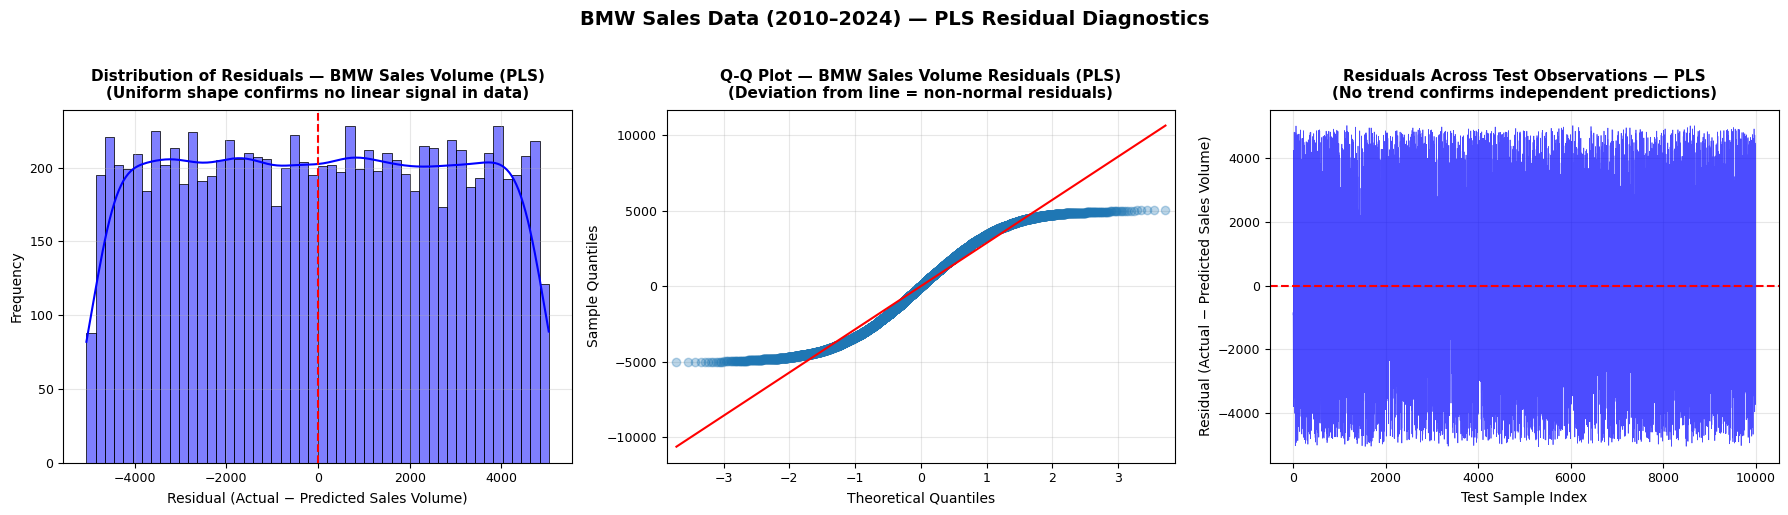

In [45]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
fig.suptitle('BMW Sales Data (2010–2024) — PLS Residual Diagnostics',
             fontsize=14, fontweight='bold', y=1.02)

# Simple style helper
def simple_style(ax, title, xlabel='', ylabel=''):
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.3)


# 1) Distribution of Residuals
simple_style(
    axes[0],
    title='Distribution of Residuals — BMW Sales Volume (PLS)\n(Uniform shape confirms no linear signal in data)',
    xlabel='Residual (Actual − Predicted Sales Volume)',
    ylabel='Frequency'
)

sns.histplot(residuals_pls, bins=50, kde=True, color='blue', ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)


# 2) Q-Q Plot
simple_style(
    axes[1],
    title='Q-Q Plot — BMW Sales Volume Residuals (PLS)\n(Deviation from line = non-normal residuals)',
    xlabel='Theoretical Quantiles',
    ylabel='Sample Quantiles'
)

sm.qqplot(residuals_pls, line='s', ax=axes[1], alpha=0.3)
axes[1].get_lines()[0].set_color('blue')   # points
axes[1].get_lines()[1].set_color('red')    # reference line


# 3) Residuals over index
simple_style(
    axes[2],
    title='Residuals Across Test Observations — PLS\n(No trend confirms independent predictions)',
    xlabel='Test Sample Index',
    ylabel='Residual (Actual − Predicted Sales Volume)'
)

axes[2].plot(residuals_pls, color='blue', linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

### Feature Importance (Top 15 by |Coefficient|)

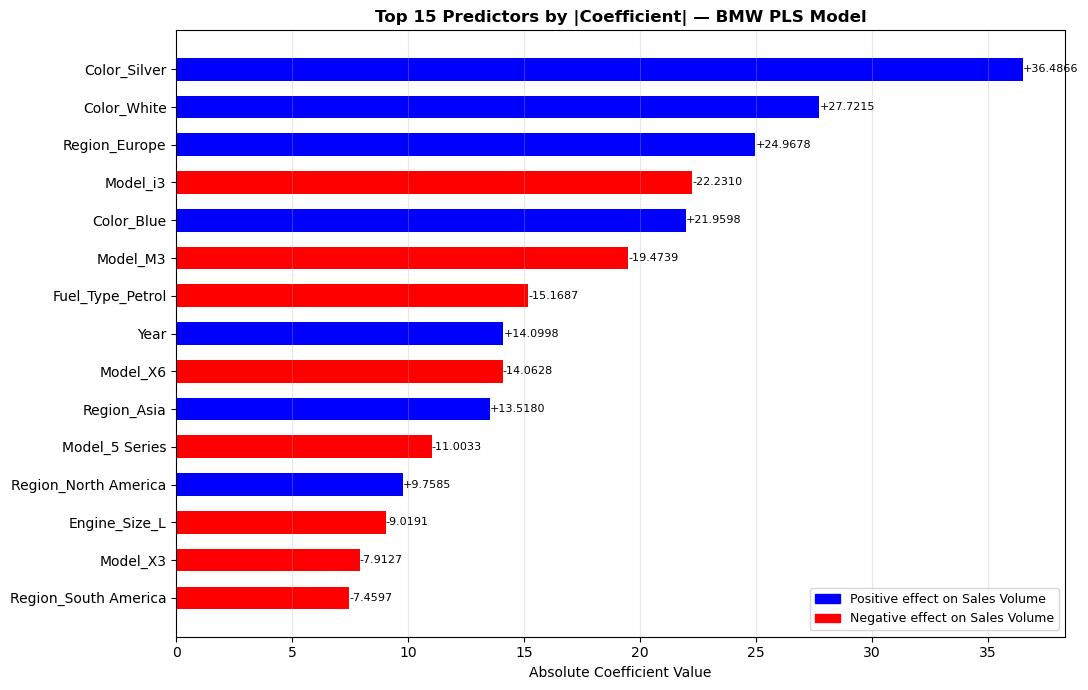

In [46]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

pls_coef_abs = pls_coef_df.copy()
pls_coef_abs['Abs'] = pls_coef_abs['Coefficient'].abs()
top15_pls = pls_coef_abs.nlargest(15, 'Abs').sort_values('Abs')

# Blue = positive, Red = negative
colors_pls = ['blue' if c > 0 else 'red' for c in top15_pls['Coefficient']]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.barh(top15_pls['Feature'], top15_pls['Abs'], color=colors_pls, height=0.6)

# Add coefficient labels
for i, (val, coef) in enumerate(zip(top15_pls['Abs'], top15_pls['Coefficient'])):
    ax.text(val + 0.0003, i, f'{coef:+.4f}', va='center', fontsize=8, color='black')

# Legend
pos_p = mpatches.Patch(color='blue', label='Positive effect on Sales Volume')
neg_p = mpatches.Patch(color='red', label='Negative effect on Sales Volume')
ax.legend(handles=[pos_p, neg_p], fontsize=9)

ax.set_xlabel('Absolute Coefficient Value')
ax.set_title('Top 15 Predictors by |Coefficient| — BMW PLS Model', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### OLS vs PLS — Full Comparison

In [47]:
comparison_models = pd.DataFrame({
    'Metric'      : ['MAE', 'RMSE', 'MSE', 'R²', 'Adjusted R²'],
    'OLS — Train' : [mae_train_ols,     rmse_train_ols,     mse_train_ols,     r2_train_ols,     adj_r2_train_ols],
    'OLS — Test'  : [mae_test_ols,      rmse_test_ols,      mse_test_ols,      r2_test_ols,      adj_r2_test_ols],
    'PLS — Train' : [mae_pls_train,     rmse_pls_train,     mse_pls_train,     r2_pls_train,     adj_r2_pls_train],
    'PLS — Test'  : [mae_pls_test,      rmse_pls_test,      mse_pls_test,      r2_pls_test,      adj_r2_pls]
})

display(comparison_models.style.format({
    'OLS — Train': '{:.4f}',
    'OLS — Test' : '{:.4f}',
    'PLS — Train': '{:.4f}',
    'PLS — Test' : '{:.4f}'
}))

,Metric,OLS — Train,OLS — Test,PLS — Train,PLS — Test
0,MAE,2469.7984,2477.1308,2469.7984,2477.1308
1,RMSE,2855.5749,2859.7777,2855.5749,2859.7776
2,MSE,8154308.2628,8178328.2502,8154308.2629,8178327.9579
3,R²,0.0005,-0.0009,0.0005,-0.0009
4,Adjusted R²,-0.0002,-0.0037,0.0002,-0.0019
